# Diabetes-Obesity Co-Hotspots in Greater Houston Were Associated with Social Vulnerability and Limited Food Access

**Yash Nirmal Ganatra, Michael E. DeBakey High School for Health Professions, Houston, Texas, USA**

**Project Description**

This notebook reproduces the data preparation, spatial analysis, statistical testing, and figure generation used in the study *“Diabetes-Obesity Co-Hotspots in Greater Houston Were Associated with Social Vulnerability and Limited Food Access.”* The analysis integrates publicly available datasets from CDC PLACES, CDC/ATSDR Social Vulnerability Index, the USDA Food Access Research Atlas, and U.S. Census tract boundary files. The workflow harmonizes datasets to 2010 census tracts using area-weighted crosswalks, identifies diabetes-obesity co-hotspots based on prevalence thresholds, evaluates associations with social vulnerability and low-income low-access food environments, and tests spatial clustering using Moran’s I. The notebook produces the statistical results and figures reported in the manuscript.

**Connect Google Drive to Colab**

The following cell connects Google Drive to the Colab session so files stored in Drive can be accessed directly from the notebook. This is usually one of the first setup steps because it makes it possible to load input data, save outputs, and keep work stored in a persistent location instead of temporary Colab storage. After running this cell and completing Google sign-in, the Drive folder becomes available inside the notebook file system.

In [ ]:
# Google Drive Mount
# Input: Google account access and the Drive mount location.
# Output: Google Drive connected in Colab so files can be read and saved.

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Load the main analysis libraries**

The following cell imports the core Python libraries used throughout the project. These tools support table handling, numeric calculations, mapping, statistical analysis, spatial neighborhood building, Moran’s I spatial autocorrelation, and figure creation. Loading them at the start prepares the notebook for the main data processing, geographic analysis, and visualization steps that follow.

In [ ]:
# Load Main Libraries
# Input: Installed Python packages for tables, maps, statistics, spatial analysis, and plotting.
# Output: Imported tools used throughout the analysis.

import pandas as pd
import numpy as np
import geopandas as gpd
from scipy import stats
from libpysal.weights import Queen
from esda.moran import Moran
import matplotlib.pyplot as plt

**Load the main datasets and census tract map**

The following cell reads the main files used in the study into memory from Google Drive. These include the PLACES health estimates, CDC Social Vulnerability Index data, USDA food access data, the census tract crosswalk table, and the 2010 Texas census tract boundary shapefile. Together, these files provide the health, social, food access, and geographic information needed for later cleaning, matching, merging, and spatial analysis. The final print statements give a quick check that each file loaded successfully by showing the number of rows or map features available.

In [ ]:
# Load Study Datasets and Census Tract Map
# Input: PLACES health data, CDC Social Vulnerability Index data, USDA food access data,
# Census tract crosswalk table, and 2010 Texas census tract polygons.
# Output: Data tables and tract boundary map loaded into memory for later merging and analysis.

base = "/content/drive/MyDrive/Census_Tract_Analysis_Project"

places = pd.read_csv(
    f"{base}/places_tract_tx_9county_filtered.csv",
    dtype=str
)

svi = pd.read_csv(
    f"{base}/svi_2022_us_tract_filtered.csv",
    dtype=str
)

food = pd.read_excel(
    f"{base}/usda_food_access_atlas_2019_filtered.xlsx",
    dtype=str
)

xwalk = pd.read_csv(
    f"{base}/tab20_tract20_tract10_natl.txt",
    sep="|",
    dtype=str
)

tracts2010 = gpd.read_file(
    f"{base}/cb_2010_tx_tract_500k/gz_2010_48_140_00_500k.shp"
)

# Quick row counts to confirm files loaded correctly
print("PLACES rows:", len(places))
print("SVI rows:", len(svi))
print("Food rows:", len(food))
print("Crosswalk rows:", len(xwalk))
print("Tract polygons:", len(tracts2010))

PLACES rows: 4788
SVI rows: 1603
Food rows: 1068
Crosswalk rows: 126450
Tract polygons: 5259


**Prepare the PLACES health indicators by census tract**

The following cell cleans and reshapes the PLACES health data into a tract-level table that is ready for analysis. It first pulls the 11-digit census tract ID from the text field, then converts the health values into numeric form so they can be used in calculations. Next, it keeps only the three study measures: diabetes, obesity, and no leisure-time physical activity. The data is then reorganized from long form to wide form so each census tract appears once, with separate columns for the three health indicators. Finally, the columns are renamed to shorter and clearer variable names, and a preview is shown to confirm the result.

In [ ]:
# Prepare PLACES Health Indicators by Census Tract
# Input: PLACES table containing health measures and tract identifiers within text fields.
# Output: One clean table with one row per census tract and three health indicators.

# Extract the 11-digit census tract GEOID from the LocationName field
places["geoid_tract20"] = places["LocationName"].str.extract(r"(\d{11})")

# Convert the health value column to numeric so it can be analyzed
places["Data_Value"] = pd.to_numeric(places["Data_Value"], errors="coerce")

# Keep only the three health measures used in the study
places = places[
    places["Measure"].isin([
        "Diagnosed diabetes among adults",
        "Obesity among adults",
        "No leisure-time physical activity among adults"
    ])
]

# Reshape the table so each tract has a single row and each measure becomes a column
places_pivot = places.pivot_table(
    index="geoid_tract20",
    columns="Measure",
    values="Data_Value",
    aggfunc="first"
).reset_index()

# Rename columns to short, clear variable names
places_pivot = places_pivot.rename(columns={
    "Diagnosed diabetes among adults": "diabetes_pct",
    "Obesity among adults": "obesity_pct",
    "No leisure-time physical activity among adults": "inactivity_pct"
})

# Preview the cleaned table
places_pivot.head()

Measure,geoid_tract20,diabetes_pct,inactivity_pct,obesity_pct
0,48015760100,17.4,36.2,41.4
1,48015760201,18.3,37.1,42.5
2,48015760202,13.1,28.3,36.5
3,48015760301,14.8,29.8,36.9
4,48015760302,15.1,32.9,39.2


**Prepare the Social Vulnerability Index by census tract**

The following cell cleans the CDC Social Vulnerability Index data and keeps only the fields needed for the study. It selects the tract FIPS code and the overall vulnerability ranking, converts the tract ID into a standard 11-digit census tract GEOID, and changes the ranking field into numeric form so it can be analyzed. It also replaces the dataset’s special missing-value code of -999 with a true missing value. The result is a simple tract-level table with a standardized tract ID and one overall social vulnerability score, followed by a quick preview to confirm the cleaned output.

In [ ]:
# Prepare Social Vulnerability Index by Census Tract
# Input: CDC SVI table containing tract FIPS codes and overall vulnerability ranking.
# Output: Clean table with standardized tract GEOID and numeric vulnerability score.

# Keep only the columns needed for analysis
svi_clean = svi[["FIPS", "RPL_THEMES"]].copy()

# Convert FIPS code to a standard 11-digit census tract GEOID
svi_clean["geoid_tract20"] = svi_clean["FIPS"].astype(str).str.zfill(11)

# Convert the vulnerability ranking column to numeric values
svi_clean["rpl_themes"] = pd.to_numeric(svi_clean["RPL_THEMES"], errors="coerce")

# Replace the dataset missing-value flag (-999) with proper missing values
svi_clean["rpl_themes"] = svi_clean["rpl_themes"].replace(-999, np.nan)

# Keep the final fields used in the study
svi_clean = svi_clean[["geoid_tract20", "rpl_themes"]]

# Preview the cleaned table
svi_clean.head()

,geoid_tract20,rpl_themes
0,48015760100,0.8356
1,48015760201,0.7858
2,48015760202,0.4682
3,48015760301,0.4576
4,48015760302,0.9148


**Prepare the USDA food access indicator by census tract**

The following cell cleans the USDA Food Access Atlas data and keeps the tract-level food access measure used in the study. It selects the census tract identifier and the low-income, low-access indicator, converts the tract ID into a standard 11-digit GEOID, and changes the food access field into numeric form so it can be analyzed. The result is a smaller, cleaner table with one tract identifier column and one food access indicator column, followed by a quick preview to confirm the output.

In [ ]:
# Prepare USDA Food Access Indicator by Census Tract
# Input: USDA Food Access Atlas table containing census tract identifiers and low-income, low-access indicator.
# Output: Clean table with standardized tract GEOID and numeric food access indicator.

food_clean = food[[
    "CensusTract",
    "County",
    "LILATracts_1And10"
]].copy()

# Convert CensusTract field to a standard 11-digit tract GEOID
food_clean["geoid_tract10"] = food_clean["CensusTract"].astype(str).str.zfill(11)

# Convert the food access indicator to numeric values
food_clean["lila_1and10"] = pd.to_numeric(food_clean["LILATracts_1And10"], errors="coerce")

# Keep only the tract identifier and food access indicator
food_clean = food_clean[[
    "geoid_tract10",
    "lila_1and10"
]]

# Preview the cleaned table
food_clean.head()

,geoid_tract10,lila_1and10
0,48015760100,0
1,48015760200,0
2,48015760300,0
3,48015760400,0
4,48015760501,0


**Build the census tract crosswalk with area weights**

The following cell prepares the tract crosswalk needed to connect datasets that use different census tract years. It keeps the 2020 tract ID, the matching 2010 tract ID, and the land area fields used to measure how much of each 2020 tract overlaps each 2010 tract. After standardizing the tract IDs and converting the area fields to numeric form, it calculates an area-based weight for each match. This weight represents the share of the 2020 tract that falls inside a given 2010 tract. The final result is a clean lookup table that supports weighted tract conversion during later data merging.

In [ ]:
# Build Census Tract Crosswalk with Area Weights
# Input: Crosswalk table linking 2020 census tracts to 2010 tracts with land area information.
# Output: Clean table mapping each 2020 tract to 2010 tracts with a proportional area weight.

# Keep only the columns required for tract conversion and area weighting
xwalk_clean = xwalk[[
    "GEOID_TRACT_20",
    "GEOID_TRACT_10",
    "AREALAND_TRACT_20",
    "AREALAND_PART"
]].copy()

# Convert tract identifiers to standard 11-digit GEOID format
xwalk_clean["geoid_tract20"] = xwalk_clean["GEOID_TRACT_20"].astype(str).str.zfill(11)
xwalk_clean["geoid_tract10"] = xwalk_clean["GEOID_TRACT_10"].astype(str).str.zfill(11)

# Convert land area fields to numeric values for weight calculation
xwalk_clean["AREALAND_TRACT_20"] = pd.to_numeric(xwalk_clean["AREALAND_TRACT_20"], errors="coerce")
xwalk_clean["AREALAND_PART"] = pd.to_numeric(xwalk_clean["AREALAND_PART"], errors="coerce")

# Calculate the share of each 2020 tract area that overlaps a 2010 tract
xwalk_clean["weight"] = (
    xwalk_clean["AREALAND_PART"] /
    xwalk_clean["AREALAND_TRACT_20"]
)

# Keep only the tract IDs and calculated weight used for merging datasets
xwalk_clean = xwalk_clean[[
    "geoid_tract20",
    "geoid_tract10",
    "weight"
]]

# Preview the crosswalk table
xwalk_clean.head()

,geoid_tract20,geoid_tract10,weight
0,01001020100,01001020100,0.999506
1,01001020100,01001020200,0.000494
2,01001020200,01001020200,1.000000
3,01001020300,01001020300,1.000000
4,01001020400,01001020400,1.000000


**Convert PLACES health data from 2020 tracts to 2010 tracts**

The following cell converts the PLACES health measures from 2020 census tracts to 2010 census tracts so they can be matched with other study data. It first joins the PLACES table to the tract crosswalk, then removes any records without a usable area weight. For each health measure, it creates a weighted value based on the share of the 2020 tract that overlaps a 2010 tract. These weighted values are then summed within each 2010 tract, along with the total weight, and used to calculate weighted average percentages for diabetes, obesity, and physical inactivity. The final result is a clean 2010 tract-level health table ready for merging with the other datasets.

In [ ]:
# Convert PLACES Health Data from 2020 Tracts to 2010 Tracts
# Input: PLACES health indicators by 2020 tract and tract crosswalk with area weights.
# Output: Health indicators recalculated for 2010 census tracts using weighted averages.

# Merge PLACES indicators with the tract crosswalk
places_xwalk = places_pivot.merge(
    xwalk_clean,
    on="geoid_tract20",
    how="left"
)

# Remove rows where a weight could not be calculated
places_xwalk = places_xwalk.dropna(subset=["weight"]).copy()

# Create weighted numerators for each health indicator
places_xwalk["diab_num"] = places_xwalk["diabetes_pct"] * places_xwalk["weight"]
places_xwalk["obes_num"] = places_xwalk["obesity_pct"] * places_xwalk["weight"]
places_xwalk["inact_num"] = places_xwalk["inactivity_pct"] * places_xwalk["weight"]

# Sum weighted values by 2010 tract and track the total weight
places2010 = (
    places_xwalk
    .groupby("geoid_tract10")
    .agg(
        diab_num=("diab_num", "sum"),
        obes_num=("obes_num", "sum"),
        inact_num=("inact_num", "sum"),
        weight_sum=("weight", "sum")
    )
    .reset_index()
)

# Calculate weighted average percentages for each health indicator
places2010["diabetes_pct"] = places2010["diab_num"] / places2010["weight_sum"]
places2010["obesity_pct"] = places2010["obes_num"] / places2010["weight_sum"]
places2010["inactivity_pct"] = places2010["inact_num"] / places2010["weight_sum"]

# Keep the final tract identifier and health indicators
places2010 = places2010[[
    "geoid_tract10",
    "diabetes_pct",
    "obesity_pct",
    "inactivity_pct"
]]

# Preview the converted dataset
places2010.head()

,geoid_tract10,diabetes_pct,obesity_pct,inactivity_pct
0,48015760100,17.40,41.40,36.20
1,48015760200,15.70,39.50,32.70
2,48015760300,14.95,38.05,31.35
3,48015760400,12.70,32.70,23.10
4,48015760501,12.90,33.60,24.00


**Convert Social Vulnerability Index from 2020 tracts to 2010 tracts**

The following cell converts the Social Vulnerability Index data from 2020 census tracts to 2010 census tracts so it can align with the study geography. It joins the cleaned SVI table to the tract crosswalk, keeps only records with both a valid SVI score and a usable area weight, and creates a weighted value for each tract match. These weighted values are then summed within each 2010 tract and divided by the total weight to produce a weighted average SVI score. The final output is a clean 2010 tract-level table with one overall vulnerability value for each tract.

In [ ]:
# Convert Social Vulnerability Index from 2020 Tracts to 2010 Tracts
# Input: Clean SVI scores by 2020 tract and tract crosswalk with area weights.
# Output: SVI scores recalculated for 2010 census tracts using weighted averages.

# Merge SVI data with the tract crosswalk
svi_xwalk = svi_clean.merge(
    xwalk_clean,
    on="geoid_tract20",
    how="left"
)

# Keep only rows that have both a valid SVI value and area weight
svi_xwalk = svi_xwalk.dropna(subset=["rpl_themes", "weight"]).copy()

# Create weighted numerator for the SVI score
svi_xwalk["svi_num"] = svi_xwalk["rpl_themes"] * svi_xwalk["weight"]

# Sum weighted values by 2010 tract and track the total weight
svi2010 = (
    svi_xwalk
    .groupby("geoid_tract10")
    .agg(
        svi_num=("svi_num", "sum"),
        svi_den=("weight", "sum")
    )
    .reset_index()
)

# Calculate weighted average SVI score for each 2010 tract
svi2010["rpl_themes"] = svi2010["svi_num"] / svi2010["svi_den"]

# Keep the final tract identifier and SVI score
svi2010 = svi2010[["geoid_tract10", "rpl_themes"]]

# Preview the converted dataset
svi2010.head()

,geoid_tract10,rpl_themes
0,48015760100,0.8356
1,48015760200,0.6270
2,48015760300,0.6862
3,48015760400,0.5977
4,48015760501,0.5009


**Combine the study variables into one mapped dataset**

The following cell brings the main study variables together into a single tract-level dataset and then links that dataset to the census tract map. It first merges the 2010-tract health indicators, social vulnerability scores, and food access measure so that each tract has all analysis fields in one table. That combined table is then joined to the census tract polygon layer, creating a geospatial dataset that includes both the study variables and the tract boundaries needed for mapping and spatial analysis. The final print statement shows how many tracts were successfully included in the mapped dataset.

In [ ]:
# Combine Health, Vulnerability, Food Access, and Map Data
# Input: Health indicators (PLACES), Social Vulnerability Index, food access indicator, and census tract polygons.
# Output: Final geospatial dataset where each tract contains all study variables and map geometry.

# Merge health indicators with social vulnerability and food access tables
analysis = (
    places2010
    .merge(svi2010, on="geoid_tract10", how="inner")
    .merge(food_clean, on="geoid_tract10", how="inner")
)

# Rebuild the nine-county tract layer if it has not been created yet
if "tracts9" not in globals():
    if "geoid_tract10" not in tracts2010.columns:
        tracts2010["geoid_tract10"] = (
            tracts2010["STATE"].astype(str).str.zfill(2) +
            tracts2010["COUNTY"].astype(str).str.zfill(3) +
            tracts2010["TRACT"].astype(str).str.zfill(6)
        )

    county_prefixes = [
        "48015",  # Austin
        "48039",  # Brazoria
        "48071",  # Chambers
        "48167",  # Galveston
        "48201",  # Harris
        "48291",  # Liberty
        "48339",  # Montgomery
        "48473",  # Waller
        "48157"   # Fort Bend
    ]

    tracts9 = tracts2010[
        tracts2010["geoid_tract10"].str[:5].isin(county_prefixes)
    ].copy()

# Attach the combined analysis data to the census tract polygons
gdf = tracts9.merge(
    analysis,
    on="geoid_tract10",
    how="inner"
)

# Confirm the number of tracts included in the final mapped dataset
print("Mapped analysis tracts:", len(gdf))

Mapped analysis tracts: 1065


**Build a standard census tract identifier**

The following cell creates a single standard census tract ID for each 2010 tract polygon by combining the state, county, and tract code fields. Each part is padded to the correct length so the final result is a consistent 11-digit GEOID. This standardized identifier is important because it gives the map layer the same tract key used in the analysis tables, allowing the geographic boundaries and study data to be matched correctly. The preview at the end shows the original code parts alongside the new combined tract ID.

In [ ]:
# Build Standard Census Tract Identifier
# Input: 2010 tract shapefile fields for state, county, and tract codes.
# Output: Single 11-digit GEOID used to match tract polygons with analysis tables.

# Combine state, county, and tract codes into a standard 11-digit census tract GEOID
tracts2010["geoid_tract10"] = (
    tracts2010["STATE"].astype(str).str.zfill(2) +
    tracts2010["COUNTY"].astype(str).str.zfill(3) +
    tracts2010["TRACT"].astype(str).str.zfill(6)
)

# Preview original components and the combined GEOID
tracts2010[["STATE", "COUNTY", "TRACT", "geoid_tract10"]].head()

,STATE,COUNTY,TRACT,geoid_tract10
0,48,029,110100,48029110100
1,48,029,110300,48029110300
2,48,029,110500,48029110500
3,48,029,120300,48029120300
4,48,029,120702,48029120702


**Filter the 2010 census tracts to the nine-county study area**

The following cell limits the full Texas 2010 census tract map to only the nine counties included in the Greater Houston study area. It defines the county FIPS prefixes for those counties, then keeps only the tract polygons whose tract ID begins with one of those county codes. This creates a smaller tract boundary layer that matches the study region and removes tracts outside the area of interest. The final print statement confirms how many tract polygons remain after the filter.

In [ ]:
# Filter 2010 Census Tracts to the Nine-County Study Area
# Input: 2010 census tract polygons with standardized tract GEOID.
# Output: Subset of tract polygons located within the nine counties used in the study.

# Define county FIPS prefixes representing the Houston-area study region
county_prefixes = [
    "48015",  # Austin
    "48039",  # Brazoria
    "48071",  # Chambers
    "48167",  # Galveston
    "48201",  # Harris
    "48291",  # Liberty
    "48339",  # Montgomery
    "48473",  # Waller
    "48157"   # Fort Bend
]

# Keep only tracts whose GEOID begins with one of the selected county prefixes
tracts9 = tracts2010[
    tracts2010["geoid_tract10"].str[:5].isin(county_prefixes)
].copy()

# Display the number of tract polygons retained for the study region
print("9-county tract polygons:", len(tracts9))

9-county tract polygons: 1071


**Attach the analysis variables to the census tract map**

The following cell joins the filtered 2010 census tract boundary layer with the combined study data using the shared tract GEOID. This step creates the final geospatial analysis dataset, where each tract includes both its map geometry and the full set of study variables. The print statement confirms how many tracts matched successfully, and the preview shows the structure of the completed mapped dataset.

In [ ]:
# Attach Analysis Variables to Census Tract Map
# Input: Filtered 2010 tract polygons and the combined analysis table.
# Output: Geospatial dataset where each tract includes geometry and all study variables.

# Rebuild the nine-county tract layer if it has not been created yet
if "tracts9" not in globals():
    if "geoid_tract10" not in tracts2010.columns:
        tracts2010["geoid_tract10"] = (
            tracts2010["STATE"].astype(str).str.zfill(2) +
            tracts2010["COUNTY"].astype(str).str.zfill(3) +
            tracts2010["TRACT"].astype(str).str.zfill(6)
        )

    county_prefixes = [
        "48015",  # Austin
        "48039",  # Brazoria
        "48071",  # Chambers
        "48167",  # Galveston
        "48201",  # Harris
        "48291",  # Liberty
        "48339",  # Montgomery
        "48473",  # Waller
        "48157"   # Fort Bend
    ]

    tracts9 = tracts2010[
        tracts2010["geoid_tract10"].str[:5].isin(county_prefixes)
    ].copy()

# Merge tract polygons with the analysis variables using the tract GEOID
gdf = tracts9.merge(
    analysis,
    on="geoid_tract10",
    how="inner"
)

# Confirm number of tracts successfully matched with analysis data
print("Mapped analysis tracts:", len(gdf))

# Preview the final geospatial dataset
gdf.head()

Mapped analysis tracts: 1065


,GEO_ID,STATE,COUNTY,TRACT,NAME,LSAD,CENSUSAREA,geometry,geoid_tract10,diabetes_pct,obesity_pct,inactivity_pct,rpl_themes,lila_1and10
0,1400000US48039664300,48,039,664300,6643,Tract,3.145,"POLYGON ((-95.35848 28.9537, -95.35985 28.9540...",48039664300,15.700000,42.200000,36.6,0.988700,1
1,1400000US48039660100,48,039,660100,6601,Tract,1.623,"POLYGON ((-95.23941 29.54778, -95.24355 29.547...",48039660100,11.500000,33.100000,21.7,0.186000,0
2,1400000US48039660701,48,039,660701,6607.01,Tract,3.998,"POLYGON ((-95.3309 29.55202, -95.33075 29.5442...",48039660701,10.533333,32.466667,20.7,0.332567,0
3,1400000US48039661100,48,039,661100,6611,Tract,5.442,"POLYGON ((-95.24444 29.43443, -95.24529 29.454...",48039661100,14.100000,40.300000,31.9,0.805400,0
4,1400000US48039661700,48,039,661700,6617,Tract,169.636,"POLYGON ((-95.05738 29.20065, -95.06522 29.196...",48039661700,12.500000,36.300000,25.7,0.653200,0


**Identify high-rate tracts and co-hotspots**

The following cell identifies census tracts with unusually high diabetes and obesity rates and then marks where the two overlap. It first calculates the 80th percentile cutoffs for diabetes and obesity, which serve as the threshold for defining high-rate tracts. It then creates binary flags showing whether each tract falls in the top 20 percent for diabetes, obesity, or both. Tracts meeting both conditions are labeled as co-hotspots. The final print statements report the cutoff values and the number of tracts identified in each group, which helps confirm how the hotspot definition was applied.

In [ ]:
# Identify High-Rate Tracts and Co-Hotspots
# Input: Tract dataset containing diabetes and obesity prevalence.
# Output: Binary indicators marking high-rate tracts and tracts where both conditions are high.

# Determine the 80th percentile thresholds for diabetes and obesity
diab_cut = gdf["diabetes_pct"].quantile(0.80)
obes_cut = gdf["obesity_pct"].quantile(0.80)

# Flag tracts with diabetes rates in the top 20 percent
gdf["diabetes_hot"] = (gdf["diabetes_pct"] >= diab_cut).astype(int)

# Flag tracts with obesity rates in the top 20 percent
gdf["obesity_hot"] = (gdf["obesity_pct"] >= obes_cut).astype(int)

# Identify tracts that meet both conditions (co-hotspots)
gdf["co_hotspot"] = ((gdf["diabetes_hot"] == 1) & (gdf["obesity_hot"] == 1)).astype(int)

# Display thresholds and counts of identified hotspot tracts
print("Diabetes cutoff:", diab_cut)
print("Obesity cutoff:", obes_cut)
print("Diabetes hotspot tracts:", gdf["diabetes_hot"].sum())
print("Obesity hotspot tracts:", gdf["obesity_hot"].sum())
print("Co-hotspot tracts:", gdf["co_hotspot"].sum())

Diabetes cutoff: 17.25606118130321
Obesity cutoff: 42.5
Diabetes hotspot tracts: 213
Obesity hotspot tracts: 217
Co-hotspot tracts: 162


**Standardize health rates and build a composite risk score**

The following cell puts the diabetes and obesity rates onto the same scale by converting each one to a standardized score. This makes the two measures easier to compare because both are expressed in terms of how far each tract is above or below the overall average. It then combines the two standardized values by taking their average, creating one composite score that summarizes overall metabolic risk across tracts. The preview at the end shows both the original rates and the new derived variables.

In [ ]:
# Standardize Health Rates and Build Composite Risk Score
# Input: Diabetes and obesity prevalence values for each census tract.
# Output: Standardized scores and a combined index representing overall metabolic risk.

# Convert diabetes rates to standardized z-scores for comparability
gdf["z_diabetes"] = stats.zscore(gdf["diabetes_pct"], nan_policy="omit")

# Convert obesity rates to standardized z-scores
gdf["z_obesity"] = stats.zscore(gdf["obesity_pct"], nan_policy="omit")

# Create a composite index by averaging the two standardized scores
gdf["composite"] = (gdf["z_diabetes"] + gdf["z_obesity"]) / 2

# Preview original rates and derived standardized variables
gdf[["diabetes_pct", "obesity_pct", "z_diabetes", "z_obesity", "composite"]].head()

,diabetes_pct,obesity_pct,z_diabetes,z_obesity,composite
0,15.700000,42.200000,0.489995,0.823654,0.656824
1,11.500000,33.100000,-0.543891,-0.616544,-0.580218
2,10.533333,32.466667,-0.781849,-0.716777,-0.749313
3,14.100000,40.300000,0.096133,0.522954,0.309543
4,12.500000,36.300000,-0.297728,-0.110100,-0.203914


**Check geometry completeness and validity**

The following cell performs a basic quality check on the final map layer by testing whether all census tracts have usable geometry. It reports how many tracts are missing geometry altogether and how many have invalid shapes that could cause problems in mapping or spatial analysis. This quick check helps confirm that the geospatial dataset is structurally sound before moving into later spatial calculations and map creation.

In [ ]:
# Check Geometry Completeness and Validity
# Input: Final geospatial dataset containing tract geometries.
# Output: Counts of missing and invalid geometries to confirm the map layer is usable.

# Count tracts with missing geometry
print("Missing geometry:", gdf["geometry"].isna().sum())

# Count tracts with invalid geometry shapes
print("Invalid geometry:", (~gdf.is_valid).sum())

Missing geometry: 0
Invalid geometry: 0


**Test overall spatial clustering with Moran’s I**

The following cell checks whether the composite health risk score is randomly spread across census tracts or tends to cluster in nearby areas. It first builds a spatial neighbor structure using Queen contiguity, which treats tracts as neighbors when they share either a boundary or a corner. The weights are then standardized so each tract’s neighboring influence is placed on a comparable scale. Moran’s I is calculated with 999 random permutations to measure whether similar values are located near each other more often than expected by chance. The printed results report the Moran’s I value, permutation-based p-value, and z-score, which together show the strength and statistical significance of the spatial clustering pattern.

In [ ]:
# Global Spatial Autocorrelation Test (Moran's I)
# Input: Composite health risk score for each tract and tract polygon geometry.
# Output: Moran's I statistic, permutation p-value, and z-score indicating spatial clustering.

from libpysal.weights import Queen
from esda.moran import Moran

# Create spatial weights using Queen contiguity (tracts sharing a boundary or corner)
w = Queen.from_dataframe(gdf)

# Row-standardize the weights so neighboring influence sums to one
w.transform = "R"

# Compute Moran's I to test whether the composite score is spatially clustered
mi = Moran(gdf["composite"], w, permutations=999)

# Display Moran's I statistic and significance test results
print("Moran's I:", mi.I)
print("Permutation p-value:", mi.p_sim)
print("Z-score:", mi.z_sim)

/tmp/ipykernel_7740/412080438.py:9: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


Moran's I: 0.7189259295249979
Permutation p-value: 0.001
Z-score: 42.80760003536535


**Compare hotspot status with social vulnerability and food access**

The following cell tests whether co-hotspot tracts differ from other tracts in important social conditions. It first compares Social Vulnerability Index values between co-hotspot and non-hotspot tracts using the Mann-Whitney U test, a nonparametric method that does not require normal data. It then builds a 2x2 table to examine whether co-hotspots are associated with the low-income, low-access food indicator, applies a chi-square test to check whether that relationship is statistically significant, and calculates risk and odds ratios to show the strength of the association. Finally, it measures the relationship between diabetes prevalence and social vulnerability across all tracts using Spearman correlation, which captures whether higher diabetes levels tend to occur alongside higher vulnerability. Together, these results help show how the health patterns relate to broader social and food access conditions.

In [ ]:
# Statistical Comparisons Between Hotspot Status and Social Factors
# Input: Tract dataset with hotspot indicator, SVI score,
# composite diabetes-obesity score, and food access indicator.
# Output: Nonparametric test results, contingency analysis, risk measures,
# and correlation statistics.

from scipy.stats import mannwhitneyu, chi2_contingency, spearmanr
import numpy as np
import pandas as pd

# 1) Compare Social Vulnerability Index between co-hotspot and non-co-hotspot tracts
hot = gdf.loc[gdf["co_hotspot"] == 1, "rpl_themes"].dropna()
nonhot = gdf.loc[gdf["co_hotspot"] == 0, "rpl_themes"].dropna()

# Mann-Whitney U test compares SVI distributions between the two groups
u_stat, u_p = mannwhitneyu(hot, nonhot, alternative="two-sided")

print("SVI comparison by co-hotspot status")
print("Co-hotspot median SVI:", hot.median())
print("Non-co-hotspot median SVI:", nonhot.median())
print("Mann-Whitney U:", u_stat)
print("p-value:", u_p)

# 2) Examine relationship between co-hotspots and low-income/low-access food areas
ct = pd.crosstab(gdf["co_hotspot"], gdf["lila_1and10"])

print("\n2x2 Table: co_hotspot x lila_1and10")
print(ct)

# Chi-square test evaluates whether the two variables are statistically associated
chi2, chi_p, dof, expected = chi2_contingency(ct)

print("Chi-square:", chi2)
print("p-value:", chi_p)

# Risk ratio and odds ratio
a = ct.loc[1, 1] if (1 in ct.index and 1 in ct.columns) else 0
b = ct.loc[1, 0] if (1 in ct.index and 0 in ct.columns) else 0
c = ct.loc[0, 1] if (0 in ct.index and 1 in ct.columns) else 0
d = ct.loc[0, 0] if (0 in ct.index and 0 in ct.columns) else 0

risk_hot = a / (a + b) if (a + b) > 0 else np.nan
risk_non = c / (c + d) if (c + d) > 0 else np.nan
risk_ratio = risk_hot / risk_non if pd.notna(risk_non) and risk_non > 0 else np.nan
odds_ratio = (a * d) / (b * c) if b > 0 and c > 0 else np.nan

print("Risk ratio:", risk_ratio)
print("Odds ratio:", odds_ratio)

# 3) Association between combined diabetes-obesity burden and social vulnerability
# Spearman correlation evaluates monotonic relationship between the variables
rho, rho_p = spearmanr(
    gdf["composite"],
    gdf["rpl_themes"],
    nan_policy="omit"
)

print("\nSpearman correlation: composite diabetes-obesity score vs SVI")
print("Spearman rho:", rho)
print("p-value:", rho_p)

SVI comparison by co-hotspot status
Co-hotspot median SVI: 0.94745
Non-co-hotspot median SVI: 0.6185
Mann-Whitney U: 132976.5
p-value: 7.225039258024352e-62

2x2 Table: co_hotspot x lila_1and10
lila_1and10    0    1
co_hotspot           
0            794  109
1            116   46
Chi-square: 28.135492427201513
p-value: 1.1311237079404211e-07
Risk ratio: 2.3523615358477743
Odds ratio: 2.8886428345460295

Spearman correlation: composite diabetes-obesity score vs SVI
Spearman rho: 0.8720627305913818
p-value: 0.0


**Create county boundaries and label points from census tracts**

The following cell builds a county-level map layer from the nine-county tract polygons. It starts from a copy of the tract data, extracts the county code from each tract ID, and matches those codes to county names. The tract polygons are then merged by county to create one boundary for each county instead of many tract shapes. A clean county name field is kept for consistent labeling, and a representative point is calculated inside each county polygon so county names can be placed clearly on later maps.

In [ ]:
# Create County Boundaries from 2010 Census Tracts
# Input: 2010 tract polygons for the nine-county study area.
# Output: County boundary layer with clean county names and label points.

import geopandas as gpd
import matplotlib.pyplot as plt

# Work from a copy so the tract layer used in later maps stays unchanged
counties = tracts9.copy()

# Extract 5-digit county FIPS code from the tract GEOID
counties["countyfp"] = counties["geoid_tract10"].str[:5]

# Map county codes to county names
county_name_map = {
    "48015": "Austin",
    "48039": "Brazoria",
    "48071": "Chambers",
    "48157": "Fort Bend",
    "48167": "Galveston",
    "48201": "Harris",
    "48291": "Liberty",
    "48339": "Montgomery",
    "48473": "Waller"
}

# Create a clean county name field for dissolve and labeling
counties["county_name"] = counties["countyfp"].map(county_name_map)

# Dissolve tract polygons into county polygons
counties = counties.dissolve(by="county_name", as_index=False)

# Create a standard name field for labeling
counties["NAME"] = counties["county_name"]

# Compute label points for county names
counties["label_point"] = counties.geometry.representative_point()

**Map the nine-county study area with county shading and tract boundaries**

The following cell creates an overview map of the study area. It draws each county with light shading to make the county extents easy to see, then overlays the census tract boundaries to show the finer tract-level geography used in the analysis. County names are placed at precomputed label points, with line breaks added for Waller and Galveston to improve readability and reduce overlap. The map is then cleaned up by adding a title, removing the axis markings, adjusting spacing, and displaying the final figure.

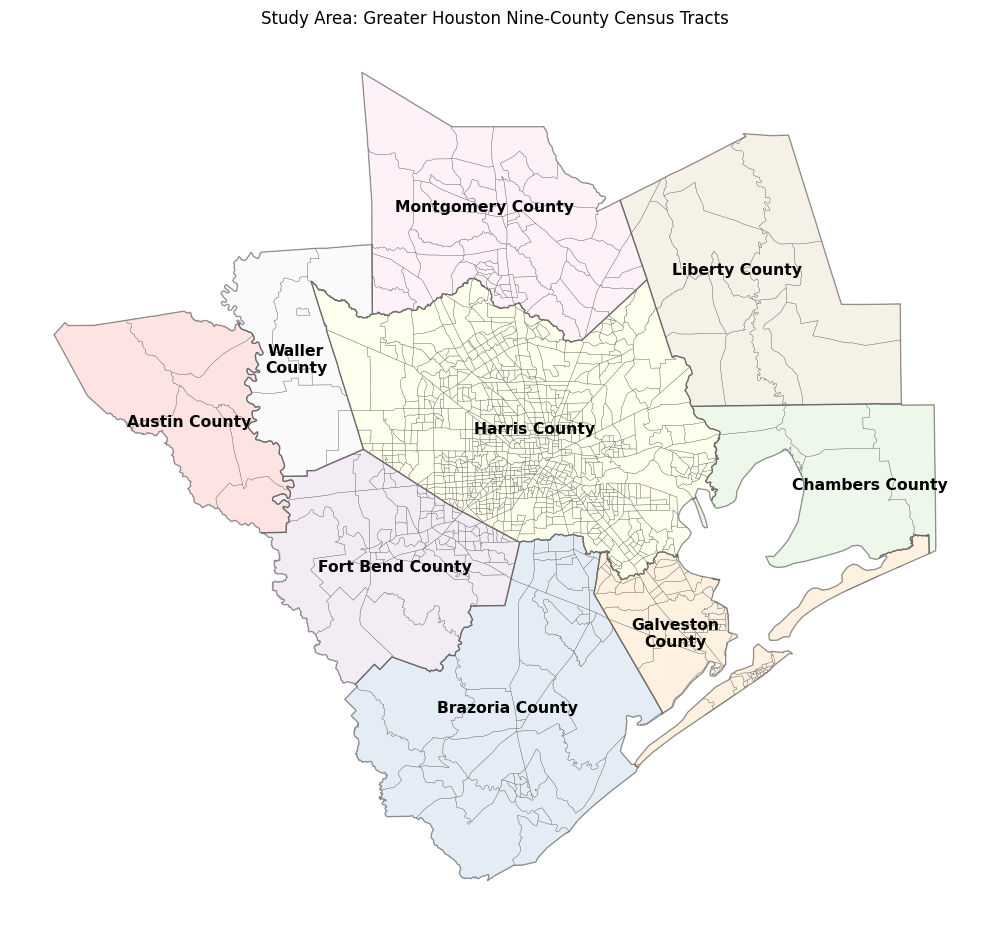

In [ ]:
# Study Area Map with County Shading and Tract Boundaries
# Input: County polygons with label positions and census tract polygons for the nine-county region.
# Output: Map showing lightly shaded counties, tract boundaries, and county labels.

import matplotlib.pyplot as plt

# Create map canvas and plotting axis
fig, ax = plt.subplots(figsize=(10,10))

# Draw counties with light color shading to show county extents
counties.plot(
    ax=ax,
    column="NAME",
    cmap="Pastel1",
    edgecolor="black",
    linewidth=1,
    alpha=0.35
)

# Overlay tract boundaries to show tract-level geography
tracts9.boundary.plot(
    ax=ax,
    color="#666666",
    linewidth=0.2
)

# Add county labels at precomputed label points
for idx, row in counties.iterrows():

    # Split labels for Waller and Galveston to improve readability
    if row["NAME"] == "Waller":
        label = "Waller\nCounty"
    elif row["NAME"] == "Galveston":
        label = "Galveston\nCounty"
    else:
        label = f"{row['NAME']} County"

    ax.text(
        row["label_point"].x,
        row["label_point"].y,
        label,
        fontsize=11.25,
        ha="center",
        va="center",
        weight="bold"
    )

# Add descriptive map title
ax.set_title("Study Area: Greater Houston Nine-County Census Tracts")

# Remove axes for cleaner cartographic appearance
ax.set_axis_off()

# Adjust layout spacing
plt.tight_layout()

# Save figure as SVG
plt.savefig("study_area_map.svg", format="svg", bbox_inches="tight")

# Render the map
plt.show()

**Map diabetes prevalence by census tract**

The following cell creates a choropleth map showing how diabetes prevalence varies across census tracts in the nine-county study area. Tracts are shaded using six quantile-based classes so the values are grouped into evenly sized ranges, making spatial differences easier to compare across the region. County boundaries are drawn on top to provide geographic reference, and county names are placed at preset label points. A thin white outline is added around each label so the text remains readable over the colored tract background. The cell finishes by adding a title, removing axis markings, tightening the layout, and displaying the final map.

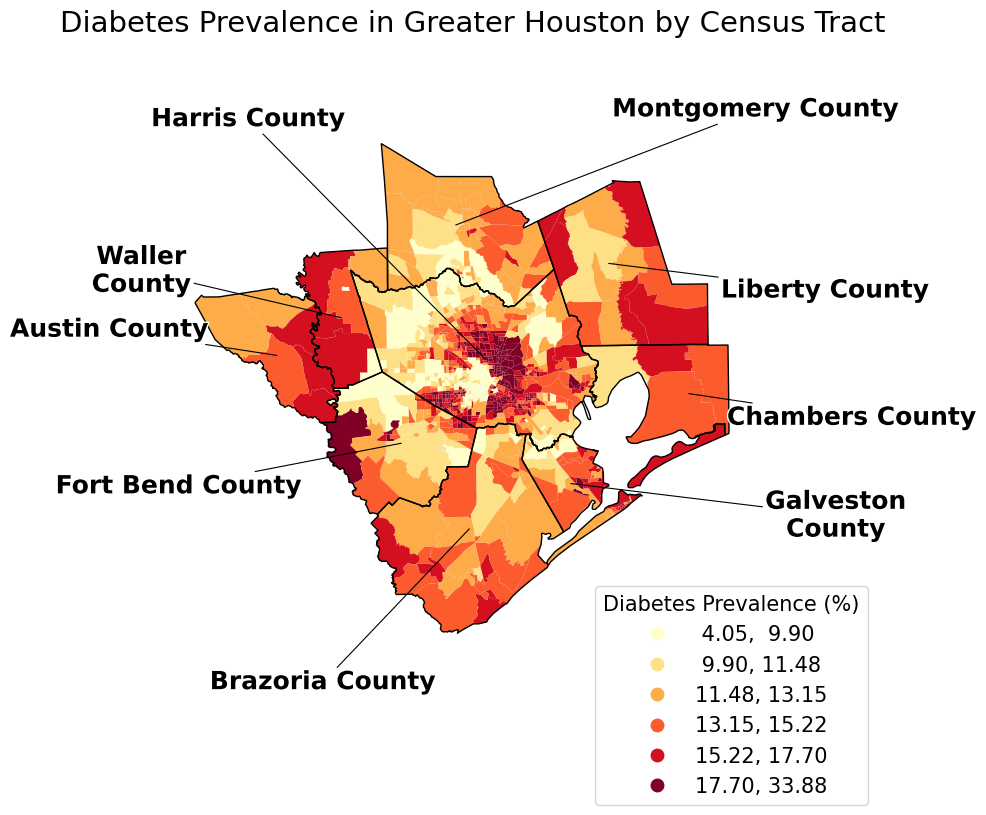

In [ ]:
# Diabetes Prevalence Map by Census Tract
# Input: Tract geospatial dataset containing diabetes prevalence and county boundary layer with label positions.
# Output: Choropleth map showing diabetes prevalence by tract with county boundaries and labeled counties.

import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(10, 12))

# Draw tract-level diabetes prevalence using quantile classes
gdf.plot(
    column="diabetes_pct",
    scheme="quantiles",
    k=6,
    cmap="YlOrRd",
    legend=True,
    edgecolor="#d9d9d9",
    linewidth=0.02,
    ax=ax,
    legend_kwds={
        "title": "Diabetes Prevalence (%)",
        "loc": "lower right",
        "fontsize": 15,
        "title_fontsize": 15,
        "bbox_to_anchor": (1, -0.18)
    }
)

# Overlay county boundaries to show county divisions
counties.boundary.plot(ax=ax, color="black", linewidth=1)

xmin, ymin, xmax, ymax = counties.total_bounds
xspan = xmax - xmin
yspan = ymax - ymin

label_positions = {
    "Austin": (xmin - 0.16 * xspan, ymin + 0.62 * yspan),
    "Waller": (xmin - 0.10 * xspan, ymin + 0.74 * yspan),
    "Montgomery": (xmax + 0.05 * xspan, ymax + 0.07 * yspan),
    "Liberty": (xmax + 0.18 * xspan, ymin + 0.70 * yspan),
    "Chambers": (xmax + 0.23 * xspan, ymin + 0.44 * yspan),
    "Galveston": (xmax + 0.20 * xspan, ymin + 0.24 * yspan),
    "Brazoria": (xmin + 0.24 * xspan, ymin - 0.10 * yspan),
    "Fort Bend": (xmin - 0.03 * xspan, ymin + 0.30 * yspan),
    "Harris": (xmin + 0.10 * xspan, ymax + 0.05 * yspan),
}

# Place county labels using stored label points
for idx, row in counties.iterrows():

    # Split Waller and Galveston labels onto two lines for better placement
    if row["NAME"] == "Waller":
        label = "Waller\nCounty"
    elif row["NAME"] == "Galveston":
        label = "Galveston\nCounty"
    else:
        label = f"{row['NAME']} County"

    anchor = row["label_point"]
    lx, ly = label_positions[row["NAME"]]

    txt = ax.annotate(
        label,
        xy=(anchor.x, anchor.y),
        xytext=(lx, ly),
        fontsize=18,
        ha="center",
        va="center",
        weight="bold",
        color="black",
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=0.8,
            shrinkA=0,
            shrinkB=0,
            connectionstyle="arc3,rad=0"
        )
    )

    # Apply thin white outline around text to improve readability on colored tracts
    txt.set_path_effects([
        pe.Stroke(linewidth=2, foreground="white"),
        pe.Normal()
    ])

# Add map title
ax.set_title("Diabetes Prevalence in Greater Houston by Census Tract", pad=28, fontsize=21)

ax.set_xlim(xmin - 0.24 * xspan, xmax + 0.28 * xspan)
ax.set_ylim(ymin - 0.14 * yspan, ymax + 0.15 * yspan)

# Remove axes for cleaner map display
ax.set_axis_off()

# Adjust layout spacing
plt.tight_layout()

# Save figure as SVG
plt.savefig("diabetes_prevalence_map.svg", format="svg", bbox_inches="tight")

# Display the map
plt.show()

**Map obesity prevalence by census tract**

The following cell creates a choropleth map showing how obesity prevalence varies across census tracts in the nine-county study area. Tracts are shaded using six quantile-based classes so the distribution can be compared more clearly across the region. County boundaries are added on top to show the county divisions, and county names are placed at preset label points for geographic reference. A thin white outline is added around the labels so the text stays readable over the colored tract background. The cell then adds a title, removes axis markings, adjusts spacing, and displays the final map.

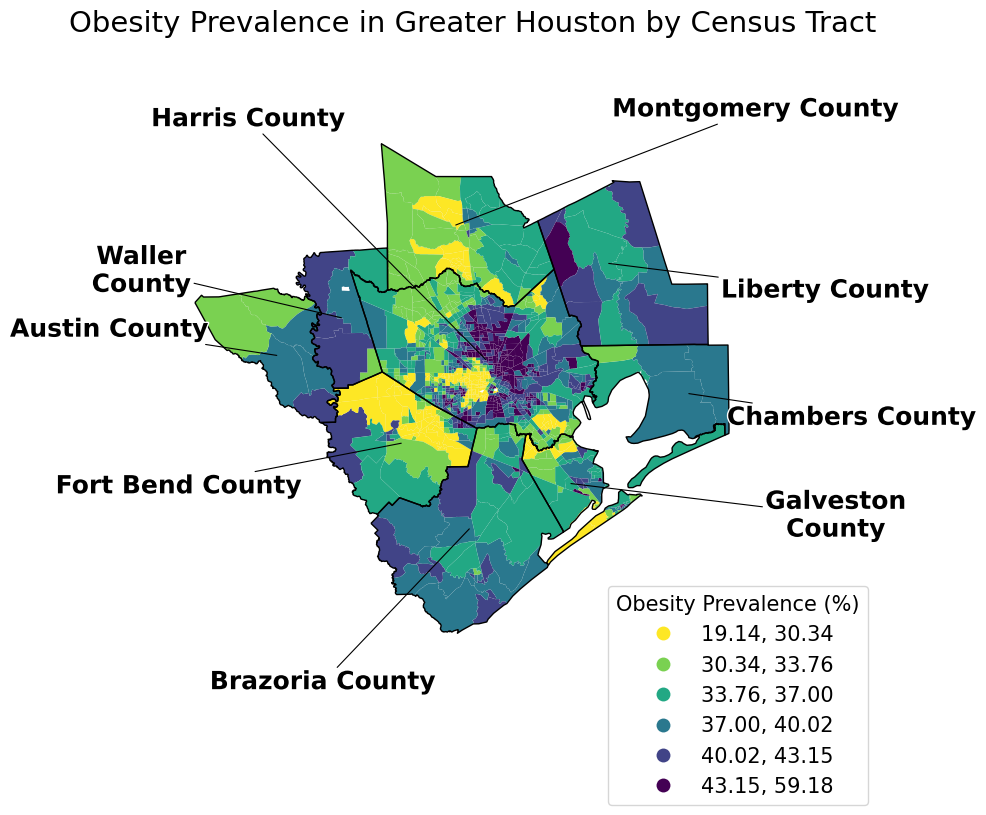

In [ ]:
# Obesity Prevalence Map by Census Tract
# Input: Geospatial tract dataset containing obesity prevalence and county boundary layer with label points.
# Output: Choropleth map showing obesity prevalence by tract with county boundaries and labeled counties.

import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(10, 12))

# Draw tract-level obesity prevalence using quantile classification
gdf.plot(
    column="obesity_pct",
    scheme="quantiles",
    k=6,
    cmap="viridis_r",
    legend=True,
    edgecolor="#d9d9d9",
    linewidth=0.02,
    ax=ax,
    legend_kwds={
        "title": "Obesity Prevalence (%)",
        "loc": "lower right",
        "fontsize": 15,
        "title_fontsize": 15,
        "bbox_to_anchor": (1, -0.18)
    }
)

# Overlay county boundaries to show county divisions
counties.boundary.plot(ax=ax, color="black", linewidth=1)

xmin, ymin, xmax, ymax = counties.total_bounds
xspan = xmax - xmin
yspan = ymax - ymin

label_positions = {
    "Austin": (xmin - 0.16 * xspan, ymin + 0.62 * yspan),
    "Waller": (xmin - 0.10 * xspan, ymin + 0.74 * yspan),
    "Montgomery": (xmax + 0.05 * xspan, ymax + 0.07 * yspan),
    "Liberty": (xmax + 0.18 * xspan, ymin + 0.70 * yspan),
    "Chambers": (xmax + 0.23 * xspan, ymin + 0.44 * yspan),
    "Galveston": (xmax + 0.20 * xspan, ymin + 0.24 * yspan),
    "Brazoria": (xmin + 0.24 * xspan, ymin - 0.10 * yspan),
    "Fort Bend": (xmin - 0.03 * xspan, ymin + 0.30 * yspan),
    "Harris": (xmin + 0.10 * xspan, ymax + 0.05 * yspan),
}

# Place county labels at precomputed label locations
for idx, row in counties.iterrows():

    # Split Waller and Galveston labels onto two lines for readability
    if row["NAME"] == "Waller":
        label = "Waller\nCounty"
    elif row["NAME"] == "Galveston":
        label = "Galveston\nCounty"
    else:
        label = f"{row['NAME']} County"

    anchor = row["label_point"]
    lx, ly = label_positions[row["NAME"]]

    txt = ax.annotate(
        label,
        xy=(anchor.x, anchor.y),
        xytext=(lx, ly),
        fontsize=18,
        ha="center",
        va="center",
        weight="bold",
        color="black",
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=0.8,
            shrinkA=0,
            shrinkB=0,
            connectionstyle="arc3,rad=0"
        )
    )

    # Apply thin white outline around labels to improve readability over colored tracts
    txt.set_path_effects([
        pe.Stroke(linewidth=2, foreground="white"),
        pe.Normal()
    ])

# Add descriptive map title
ax.set_title("Obesity Prevalence in Greater Houston by Census Tract", pad=28, fontsize=21)

ax.set_xlim(xmin - 0.24 * xspan, xmax + 0.28 * xspan)
ax.set_ylim(ymin - 0.14 * yspan, ymax + 0.15 * yspan)

# Remove axes for cleaner map presentation
ax.set_axis_off()

# Adjust layout spacing
plt.tight_layout()

# Save figure as SVG
plt.savefig("obesity_prevalence_map.svg", format="svg", bbox_inches="tight")

# Display the map
plt.show()

**Map diabetes-obesity co-hotspots by census tract**

The following cell creates a map that highlights where diabetes and obesity hotspot tracts overlap within the nine-county study area. Tracts that are not co-hotspots are first drawn in light gray as the background, and tracts identified as co-hotspots are then overlaid in red so the overlap areas stand out clearly. County boundaries are added for geographic reference, and the map extent is fixed to the full tract layer so the scale stays consistent with the other figures in the study. County labels are placed at stored label points, with line breaks used where needed for better fit. A simple legend explains the two tract categories, and the cell finishes by adding a title, removing axis markings, adjusting spacing, and displaying the final map.

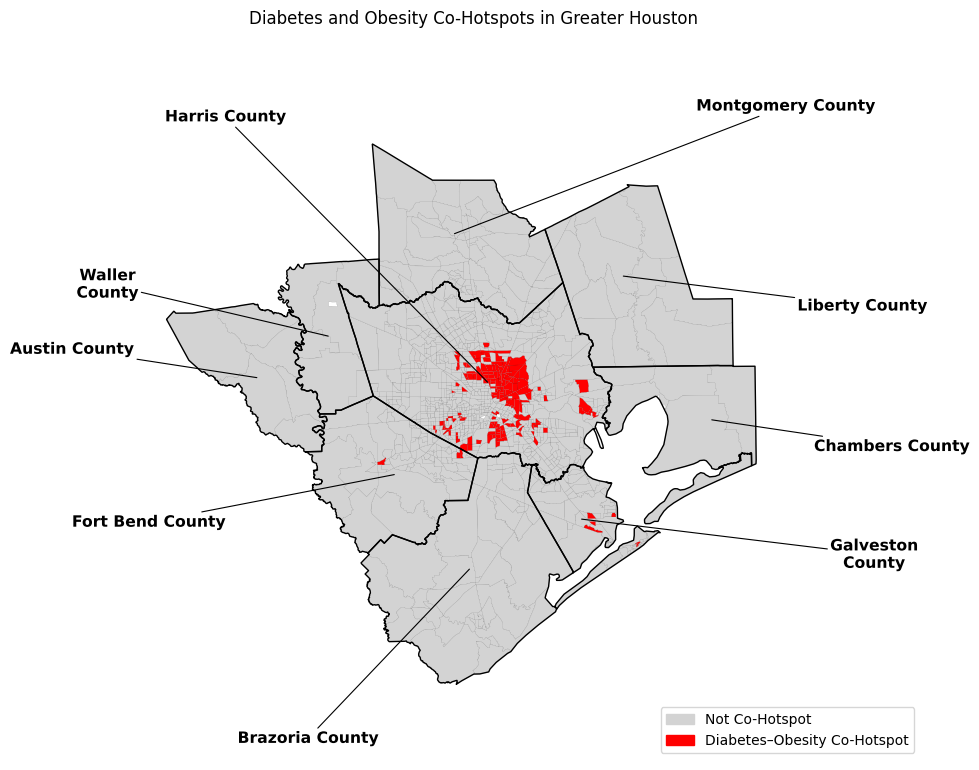

In [ ]:
# Diabetes–Obesity Co-Hotspot Map by Census Tract
# Input: Tract geospatial dataset with co-hotspot status and county boundary layer with label points.
# Output: Map showing co-hotspot tracts with county boundaries, county labels, and a legend.

import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

# Create map canvas and plotting axis
fig, ax = plt.subplots(figsize=(10,10))

# Draw non-co-hotspot tracts as the background layer
gdf[gdf["co_hotspot"] == 0].plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=0.05
)

# Draw diabetes-obesity co-hotspot tracts on top
gdf[gdf["co_hotspot"] == 1].plot(
    ax=ax,
    color="red",
    edgecolor="black",
    linewidth=0.05
)

# Overlay county boundaries for geographic reference
counties.boundary.plot(ax=ax, color="black", linewidth=1)

# Fix map extent so the map scale stays consistent with the other figures
xmin, ymin, xmax, ymax = counties.total_bounds
xspan = xmax - xmin
yspan = ymax - ymin

label_positions = {
    "Austin": (xmin - 0.16 * xspan, ymin + 0.62 * yspan),
    "Waller": (xmin - 0.10 * xspan, ymin + 0.74 * yspan),
    "Montgomery": (xmax + 0.05 * xspan, ymax + 0.07 * yspan),
    "Liberty": (xmax + 0.18 * xspan, ymin + 0.70 * yspan),
    "Chambers": (xmax + 0.23 * xspan, ymin + 0.44 * yspan),
    "Galveston": (xmax + 0.20 * xspan, ymin + 0.24 * yspan),
    "Brazoria": (xmin + 0.24 * xspan, ymin - 0.10 * yspan),
    "Fort Bend": (xmin - 0.03 * xspan, ymin + 0.30 * yspan),
    "Harris": (xmin + 0.10 * xspan, ymax + 0.05 * yspan),
}

# Add county labels at stored label positions
for idx, row in counties.iterrows():

    # Split Waller and Galveston labels onto two lines for better fit
    if row["NAME"] == "Waller":
        label = "Waller\nCounty"
    elif row["NAME"] == "Galveston":
        label = "Galveston\nCounty"
    else:
        label = f"{row['NAME']} County"

    anchor = row["label_point"]
    lx, ly = label_positions[row["NAME"]]

    txt = ax.annotate(
        label,
        xy=(anchor.x, anchor.y),
        xytext=(lx, ly),
        fontsize=11.25,
        ha="center",
        va="center",
        weight="bold",
        color="black",
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=0.8,
            shrinkA=0,
            shrinkB=0,
            connectionstyle="arc3,rad=0"
        )
    )

    txt.set_path_effects([
        pe.Stroke(linewidth=2, foreground="white"),
        pe.Normal()
    ])

# Create legend explaining tract colors
legend_handles = [
    mpatches.Patch(color="lightgray", label="Not Co-Hotspot"),
    mpatches.Patch(color="red", label="Diabetes–Obesity Co-Hotspot")
]

# Add legend in the lower-left corner
ax.legend(handles=legend_handles, loc="lower right")

# Add descriptive map title
ax.set_title("Diabetes and Obesity Co-Hotspots in Greater Houston", pad=28)

ax.set_xlim(xmin - 0.24 * xspan, xmax + 0.28 * xspan)
ax.set_ylim(ymin - 0.14 * yspan, ymax + 0.15 * yspan)

# Remove axes for cleaner map display
ax.set_axis_off()

# Adjust layout spacing to match the other maps more closely
plt.tight_layout()

# Save figure as SVG
plt.savefig("diabetes_obesity_cohotspot_map.svg", format="svg", bbox_inches="tight")

# Display the map
plt.show()

**Compare social vulnerability by co-hotspot status with a boxplot**

The following cell creates a boxplot that compares Social Vulnerability Index values between tracts that are co-hotspots and tracts that are not. It first builds the two groups from the tract dataset, then draws side-by-side boxplots to show the center, spread, and outliers for each group. Different fill colors are used to make the comparison easier to read, and the whiskers, caps, and median lines are formatted for a cleaner appearance. The plot also includes a title, y-axis label, fixed scale, and light horizontal grid to improve readability. Sample sizes for both groups are added below the category labels so the viewer can see how many tracts are represented in each comparison.

/tmp/ipykernel_7740/598617717.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


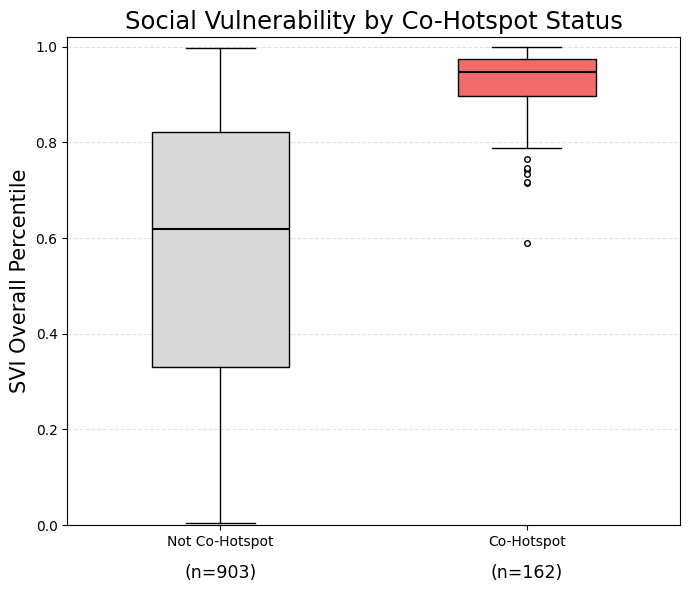

In [ ]:
# Boxplot of Social Vulnerability by Co-Hotspot Status
# Input: Social vulnerability scores grouped by tract co-hotspot status.
# Output: Boxplot comparing the distribution of SVI values between co-hotspot and non-co-hotspot tracts.

# Create figure and axis for the boxplot
fig, ax = plt.subplots(figsize=(7,6))

# Build the two data groups used in the comparison
plot_data = [
    gdf.loc[gdf["co_hotspot"] == 0, "rpl_themes"].dropna(),
    gdf.loc[gdf["co_hotspot"] == 1, "rpl_themes"].dropna()
]

# Draw boxplots for the two groups
bp = ax.boxplot(
    plot_data,
    labels=["Not Co-Hotspot", "Co-Hotspot"],
    patch_artist=True,
    widths=0.45,
    showfliers=True,
    flierprops=dict(
        marker='o',
        markersize=4,
        markerfacecolor='white',
        markeredgecolor='black',
        linestyle='none'
    )
)

# Fill each box with a different color for easier group comparison
bp["boxes"][0].set(facecolor="#d9d9d9", edgecolor="black", linewidth=1.0)
bp["boxes"][1].set(facecolor="#f26b6b", edgecolor="black", linewidth=1.0)

# Format whiskers, caps, and median lines
for whisker in bp["whiskers"]:
    whisker.set(color="black", linewidth=1.0)

for cap in bp["caps"]:
    cap.set(color="black", linewidth=1.0)

for median in bp["medians"]:
    median.set(color="black", linewidth=1.5)

# Add title, axis label, scale, and light horizontal grid
ax.set_title("Social Vulnerability by Co-Hotspot Status", fontsize=17.5)
ax.set_ylabel("SVI Overall Percentile", fontsize=15)
ax.set_ylim(0, 1.02)
ax.grid(axis="y", linestyle="--", alpha=0.35)

# Show sample size below each group label
n0 = (gdf["co_hotspot"] == 0).sum()
n1 = (gdf["co_hotspot"] == 1).sum()

ax.text(1, -0.08, f"(n={n0})", ha="center", va="top",
        transform=ax.get_xaxis_transform(), fontsize=12.5)
ax.text(2, -0.08, f"(n={n1})", ha="center", va="top",
        transform=ax.get_xaxis_transform(), fontsize=12.5)

# Adjust spacing
plt.tight_layout()

# Save figure as SVG
plt.savefig("svi_boxplot_hotspot.svg", format="svg", bbox_inches="tight")

# Display the figure
plt.show()

**Show spatial clustering with a Moran scatterplot**

The following cell creates a Moran scatterplot to visualize how each tract’s composite diabetes-obesity score relates to the average score of its neighboring tracts. It first calculates the spatial lag, which is the nearby-neighbor average for each tract, then plots tract scores against those neighbor averages. Light background shading is added to mark the four Moran quadrants, helping distinguish areas where high values cluster with high values, low values cluster with low values, or where local contrasts appear. Reference lines at zero divide the plot into those quadrants, and a fitted regression line summarizes the overall spatial pattern. The chart is completed with quadrant labels, a title, clear axis descriptions, and layout adjustments for readability.

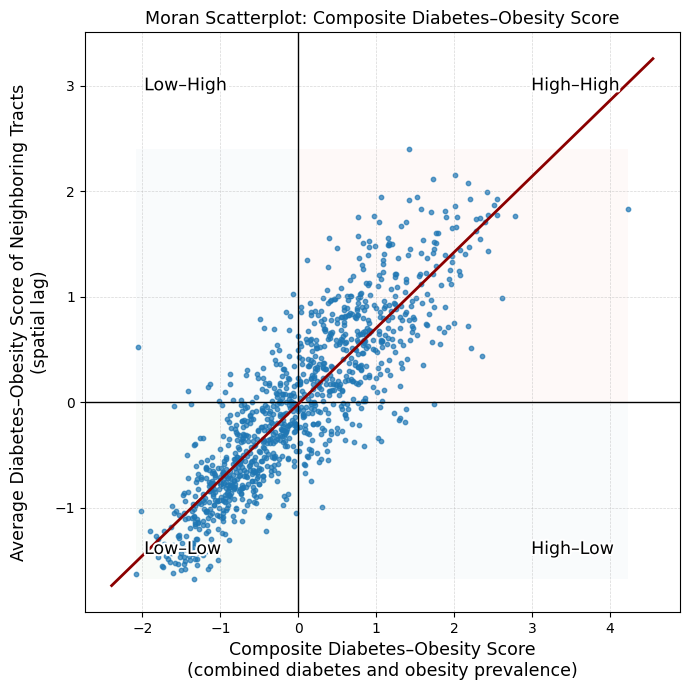

In [ ]:
# Moran Scatterplot for Composite Diabetes–Obesity Score
# Input: Composite tract score and spatial weights defining neighboring tracts.
# Output: Moran scatterplot showing the relationship between tract values and the average value of neighboring tracts.

from libpysal.weights import lag_spatial
from matplotlib.patches import Rectangle
import matplotlib.patheffects as pe

# Compute spatial lag (average composite score of neighboring tracts)
gdf["lag_composite"] = lag_spatial(w, gdf["composite"])

# Create figure for the Moran scatterplot
fig, ax = plt.subplots(figsize=(7,7))

# Plot each tract as a point: x = tract score, y = average score of neighbors
ax.scatter(
    gdf["composite"],
    gdf["lag_composite"],
    s=10,
    alpha=0.7
)

# Determine data limits used for quadrant shading
xmin, xmax = gdf["composite"].min(), gdf["composite"].max()
ymin, ymax = gdf["lag_composite"].min(), gdf["lag_composite"].max()

# Add light background shading to highlight the four Moran quadrants
ax.add_patch(Rectangle((xmin, ymin), -xmin, -ymin,
                       facecolor="#e8f5e9", alpha=0.3, zorder=0))  # Low-Low

ax.add_patch(Rectangle((0, 0), xmax, ymax,
                       facecolor="#fdecea", alpha=0.3, zorder=0))  # High-High

ax.add_patch(Rectangle((xmin, 0), -xmin, ymax,
                       facecolor="#eef2f7", alpha=0.3, zorder=0))  # Low-High

ax.add_patch(Rectangle((0, ymin), xmax, -ymin,
                       facecolor="#eef2f7", alpha=0.3, zorder=0))  # High-Low

# Draw vertical and horizontal reference lines at zero
ax.axvline(0, color="black", linewidth=1)
ax.axhline(0, color="black", linewidth=1)

# Add light gridlines to improve readability
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

# Fit and plot regression line representing spatial association
m, b = np.polyfit(gdf["composite"], gdf["lag_composite"], 1)
x_vals = np.array(ax.get_xlim())
ax.plot(x_vals, m*x_vals + b, color="darkred", linewidth=2)

# Add quadrant labels describing spatial clustering patterns
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

t1 = ax.text(xmin + 0.1*(xmax-xmin), ymax - 0.1*(ymax-ymin), "Low–High", fontsize=12.5)
t2 = ax.text(xmax - 0.25*(xmax-xmin), ymax - 0.1*(ymax-ymin), "High–High", fontsize=12.5)
t3 = ax.text(xmin + 0.1*(xmax-xmin), ymin + 0.1*(ymax-ymin), "Low–Low", fontsize=12.5)
t4 = ax.text(xmax - 0.25*(xmax-xmin), ymin + 0.1*(ymax-ymin), "High–Low", fontsize=12.5)

for t in [t1, t2, t3, t4]:
    t.set_path_effects([
        pe.Stroke(linewidth=3, foreground="white"),
        pe.Normal()
    ])

# Add title and axis descriptions
ax.set_title("Moran Scatterplot: Composite Diabetes–Obesity Score", fontsize=12.5)

ax.set_xlabel(
    "Composite Diabetes–Obesity Score\n"
    "(combined diabetes and obesity prevalence)",
    fontsize=12.5
)

ax.set_ylabel(
    "Average Diabetes–Obesity Score of Neighboring Tracts\n"
    "(spatial lag)",
    fontsize=12.5
)

# Adjust layout
plt.tight_layout()

# Save figure as SVG
plt.savefig("moran_scatterplot.svg", format="svg", bbox_inches="tight")

# Display the figure
plt.show()

**Map social vulnerability by census tract**

The following cell creates a choropleth map showing how social vulnerability varies across census tracts in the nine-county study area. Tracts are shaded using five quantile-based classes so the relative pattern of lower to higher vulnerability can be compared across the region. County boundaries are added as a light reference layer, and county names are placed at stored label points to help orient the map. A thin white outline is added around the labels so they remain readable over the shaded tract background. The cell then adds a title, removes axis markings, adjusts spacing, and displays the final map.

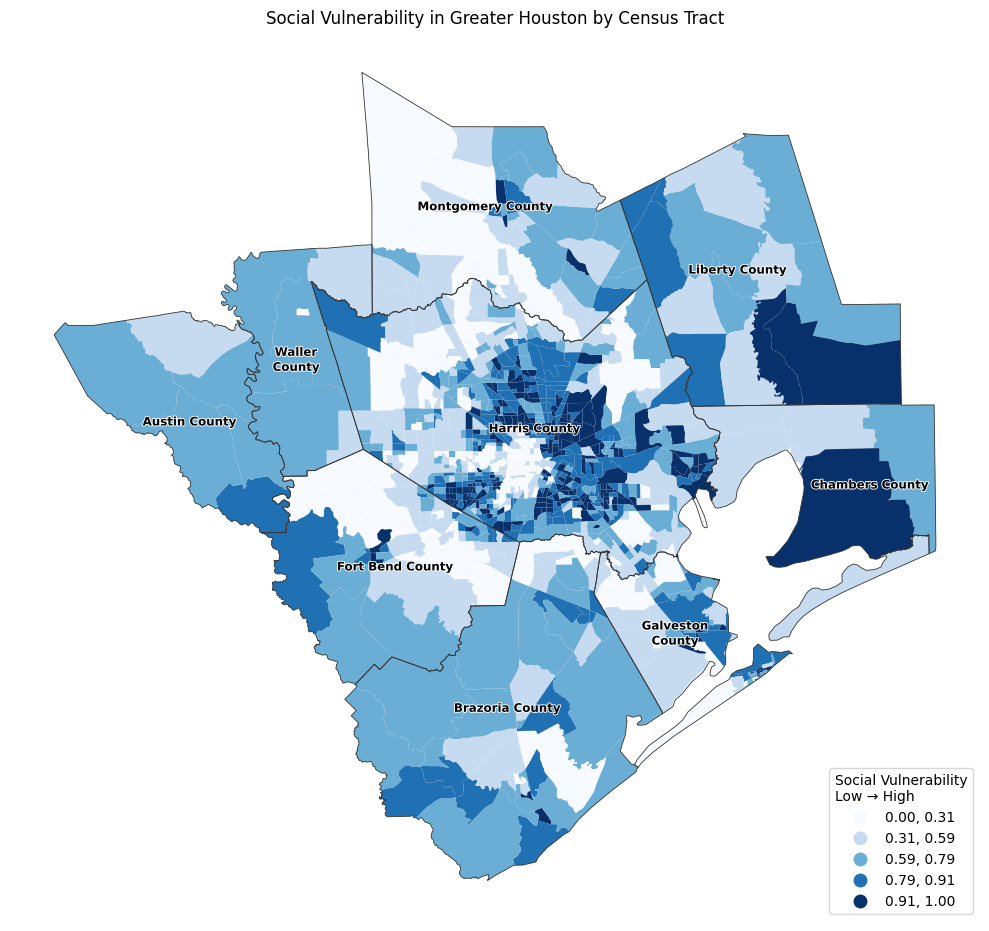

In [ ]:
# Social Vulnerability Map by Census Tract
# Input: Tract geospatial dataset containing social vulnerability scores and county boundary layer with label points.
# Output: Choropleth map showing social vulnerability by tract with county boundaries and labeled counties.

import matplotlib.patheffects as pe

# Create map canvas and plotting axis
fig, ax = plt.subplots(figsize=(10,10))

# Draw tract-level social vulnerability using quantile classes
gdf.plot(
    column="rpl_themes",
    scheme="quantiles",
    k=5,
    cmap="Blues",
    legend=True,
    edgecolor="#d9d9d9",   # light tract borders for subtle separation
    linewidth=0.02,        # thin borders to reduce visual clutter
    ax=ax,
    legend_kwds={
        "title": "Social Vulnerability\nLow → High",
        "loc": "lower right"
    }
)

# Overlay county boundaries for geographic reference
counties.boundary.plot(ax=ax, color="#333333", linewidth=0.6)

# Store map extent values
xmin, ymin, xmax, ymax = gdf.total_bounds
dx = xmax - xmin
dy = ymax - ymin

# Add county labels at stored label positions
for _, row in counties.iterrows():

    # Split Waller and Galveston labels onto two lines for better fit
    if row["NAME"] == "Waller":
        label = "Waller\nCounty"
    elif row["NAME"] == "Galveston":
        label = "Galveston\nCounty"
    else:
        label = f"{row['NAME']} County"

    txt = ax.text(
        row["label_point"].x,
        row["label_point"].y,
        label,
        fontsize=8.5,
        ha="center",
        va="center",
        color="black",
        weight="bold"
    )

    # Add a thin white outline around labels for better readability
    txt.set_path_effects([pe.withStroke(linewidth=1.3, foreground="white")])

# Add descriptive map title
ax.set_title("Social Vulnerability in Greater Houston by Census Tract")

# Remove axes for cleaner map presentation
ax.set_axis_off()

# Adjust layout spacing
plt.tight_layout()

# Save figure as SVG
plt.savefig("social_vulnerability_map.svg", format="svg", bbox_inches="tight")

# Display the map
plt.show()

**Map low-income, low-access census tracts**

The following cell creates a map that highlights census tracts classified as low-income and low-access within the nine-county study area. It first draws all tracts in light gray to provide geographic background, then overlays the tracts marked with the LILA indicator in a contrasting color so they stand out clearly. County boundaries are added for reference, and county names are placed at stored label points to help orient the map. A simple legend explains the two tract categories, and the cell finishes by adding a title, removing axis markings, adjusting spacing, and displaying the final map.

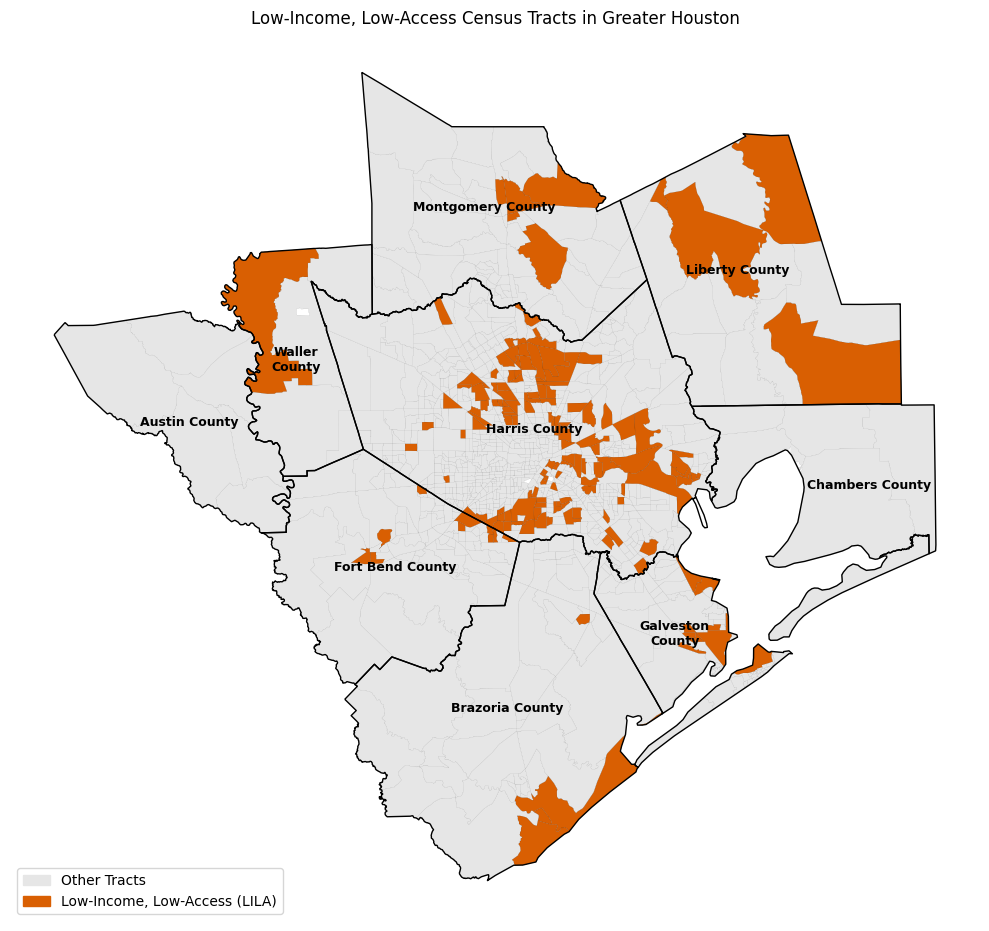

In [ ]:
# Map of Low-Income, Low-Access (LILA) Census Tracts
# Input: Tract geospatial dataset with LILA indicator and county boundary layer with label points.
# Output: Map highlighting tracts classified as low-income and low-access with county boundaries and labels.

import matplotlib.patches as mpatches

# Create map canvas and plotting axis
fig, ax = plt.subplots(figsize=(10,10))

# Draw all tracts in light gray as background context
gdf.plot(
    ax=ax,
    color="#e6e6e6",
    edgecolor="black",
    linewidth=0.03
)

# Highlight tracts identified as low-income and low-access
gdf[gdf["lila_1and10"] == 1].plot(
    ax=ax,
    color="#d95f02",   # muted orange used to emphasize LILA tracts
    edgecolor="black",
    linewidth=0.05
)

# Overlay county boundaries for geographic reference
counties.boundary.plot(ax=ax, color="black", linewidth=1)

# Place county labels at stored label locations
for idx, row in counties.iterrows():

    # Split Waller and Galveston labels onto two lines for better placement
    if row["NAME"] == "Waller":
        label = "Waller\nCounty"
    elif row["NAME"] == "Galveston":
        label = "Galveston\nCounty"
    else:
        label = f"{row['NAME']} County"

    ax.text(
        row["label_point"].x,
        row["label_point"].y,
        label,
        fontsize=9,
        ha="center",
        va="center",
        weight="bold"
    )

# Create legend explaining tract colors
legend_handles = [
    mpatches.Patch(color="#e6e6e6", label="Other Tracts"),
    mpatches.Patch(color="#d95f02", label="Low-Income, Low-Access (LILA)")
]

# Add legend to the map
ax.legend(handles=legend_handles, loc="lower left")

# Add descriptive map title
ax.set_title("Low-Income, Low-Access Census Tracts in Greater Houston")

# Remove axes for cleaner map appearance
ax.set_axis_off()

# Adjust layout spacing
plt.tight_layout()

# Save figure as SVG
plt.savefig("lila_tract_map.svg", format="svg", bbox_inches="tight")

# Display the map
plt.show()

**Sensitivity analysis for alternative hotspot thresholds**

The following cell runs a sensitivity analysis to check whether the main co-hotspot findings stay similar when the hotspot cutoff is changed from the 80th percentile to the 75th or 85th percentile. It rebuilds the diabetes, obesity, and co-hotspot flags at each threshold, counts how many tracts are identified, then compares co-hotspot and non-co-hotspot tracts on social vulnerability and the low-income, low-access food measure. It also compares the alternative co-hotspot tract sets with the 80th-percentile baseline to show how much overlap remains, and optionally summarizes county concentration if county codes are available. The final tables and printout help show whether the main pattern is stable across reasonable threshold choices.

In [ ]:
# Sensitivity Analysis for Alternative Hotspot Thresholds
# Input: Final tract dataset with diabetes, obesity, SVI, food access, and tract ID fields.
# Output: Summary tables showing how results change when hotspot thresholds are set at 75%, 80%, and 85%.

# Sensitivity analysis for matched percentile thresholds on diabetes and obesity
# This cell:
# 1) redefines diabetes and obesity hotspots at 75th, 80th, and 85th percentiles
# 2) rebuilds co-hotspots for each threshold
# 3) summarizes hotspot counts
# 4) compares SVI between co-hotspot and non-co-hotspot tracts
# 5) tests the LILA association
# 6) compares each alternative co-hotspot set to the 80th-percentile baseline
# 7) optionally summarizes county concentration if COUNTY is available in gdf

import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, chi2_contingency

# Work from a copy so the original tract dataset remains unchanged
sens_df = gdf.copy()

# Define percentile thresholds to test
thresholds = [0.75, 0.80, 0.85]

# Store co-hotspot tract sets and summary results
cohotspot_sets = {}
results = []

# Repeat the full hotspot analysis at each threshold
for q in thresholds:
    diab_cut = sens_df["diabetes_pct"].quantile(q)
    obes_cut = sens_df["obesity_pct"].quantile(q)

    # Flag diabetes hotspots, obesity hotspots, and co-hotspots at the current threshold
    diab_flag = (sens_df["diabetes_pct"] >= diab_cut).astype(int)
    obes_flag = (sens_df["obesity_pct"] >= obes_cut).astype(int)
    co_flag = ((diab_flag == 1) & (obes_flag == 1)).astype(int)

    # Save the co-hotspot tract set for later overlap comparison
    tract_set = set(sens_df.loc[co_flag == 1, "geoid_tract10"].astype(str))
    cohotspot_sets[q] = tract_set

    # Compare SVI between co-hotspot and non-co-hotspot tracts
    hot_svi = sens_df.loc[co_flag == 1, "rpl_themes"].dropna()
    nonhot_svi = sens_df.loc[co_flag == 0, "rpl_themes"].dropna()

    if len(hot_svi) > 0 and len(nonhot_svi) > 0:
        u_stat, u_p = mannwhitneyu(hot_svi, nonhot_svi, alternative="two-sided")
        hot_median_svi = hot_svi.median()
        nonhot_median_svi = nonhot_svi.median()
    else:
        u_stat, u_p = np.nan, np.nan
        hot_median_svi, nonhot_median_svi = np.nan, np.nan

    # Build a 2x2 table for co-hotspot status and LILA status
    ct = pd.crosstab(co_flag, sens_df["lila_1and10"])

    # Ensure the table always has both rows and both columns
    for idx in [0, 1]:
        if idx not in ct.index:
            ct.loc[idx] = 0
    for col in [0, 1]:
        if col not in ct.columns:
            ct[col] = 0
    ct = ct.sort_index().sort_index(axis=1)

    # Test association between co-hotspot status and LILA status
    try:
        chi2, chi_p, _, _ = chi2_contingency(ct)
    except ValueError:
        chi2, chi_p = np.nan, np.nan

    # Extract 2x2 table cell counts and calculate risk and odds ratios
    a = ct.loc[1, 1]  # co-hotspot and LILA
    b = ct.loc[1, 0]  # co-hotspot and not LILA
    c = ct.loc[0, 1]  # non-co-hotspot and LILA
    d = ct.loc[0, 0]  # non-co-hotspot and not LILA

    risk_hot = a / (a + b) if (a + b) > 0 else np.nan
    risk_non = c / (c + d) if (c + d) > 0 else np.nan
    risk_ratio = risk_hot / risk_non if pd.notna(risk_non) and risk_non > 0 else np.nan
    odds_ratio = (a * d) / (b * c) if (b > 0 and c > 0) else np.nan

    # Store summary results for the current threshold
    row = {
        "threshold_pct": int(q * 100),
        "diabetes_cutoff": diab_cut,
        "obesity_cutoff": obes_cut,
        "diabetes_hotspots_n": int(diab_flag.sum()),
        "obesity_hotspots_n": int(obes_flag.sum()),
        "co_hotspots_n": int(co_flag.sum()),
        "median_svi_non_cohotspot": nonhot_median_svi,
        "median_svi_cohotspot": hot_median_svi,
        "mannwhitney_u": u_stat,
        "mannwhitney_p": u_p,
        "lila_non_cohotspot_n": int(c),
        "not_lila_non_cohotspot_n": int(d),
        "lila_cohotspot_n": int(a),
        "not_lila_cohotspot_n": int(b),
        "chi_square": chi2,
        "chi_square_p": chi_p,
        "risk_ratio_lila": risk_ratio,
        "odds_ratio_lila": odds_ratio,
    }

    # Optionally summarize how co-hotspots are distributed across counties
    if "COUNTY" in sens_df.columns:
        county_counts = sens_df.loc[co_flag == 1, "COUNTY"].astype(str).value_counts()
        total_co = int(co_flag.sum())

        harris_n = int(county_counts.get("201", 0))
        fortbend_n = int(county_counts.get("157", 0))
        brazoria_n = int(county_counts.get("039", 0))
        galveston_n = int(county_counts.get("167", 0))
        chambers_n = int(county_counts.get("071", 0))

        row["harris_cohotspots_n"] = harris_n
        row["harris_share_pct"] = (100 * harris_n / total_co) if total_co > 0 else np.nan
        row["fortbend_cohotspots_n"] = fortbend_n
        row["brazoria_cohotspots_n"] = brazoria_n
        row["galveston_cohotspots_n"] = galveston_n
        row["chambers_cohotspots_n"] = chambers_n

    results.append(row)

# Convert threshold summaries into a results table
sens_results = pd.DataFrame(results)

# Compare the 75th and 85th percentile co-hotspot sets with the 80th percentile baseline
baseline_set = cohotspot_sets[0.80]
comparison_rows = []

for q in [0.75, 0.85]:
    current_set = cohotspot_sets[q]
    intersection_n = len(current_set & baseline_set)
    union_n = len(current_set | baseline_set)
    jaccard = intersection_n / union_n if union_n > 0 else np.nan
    baseline_recovered_pct = (100 * intersection_n / len(baseline_set)) if len(baseline_set) > 0 else np.nan

    comparison_rows.append({
        "comparison": f"{int(q*100)}th vs 80th",
        "shared_cohotspots_n": intersection_n,
        "union_cohotspots_n": union_n,
        "jaccard_similarity": jaccard,
        "pct_of_80th_cohotspots_retained": baseline_recovered_pct
    })

# Convert overlap summaries into a table
overlap_results = pd.DataFrame(comparison_rows)

# Format decimal output for easier reading
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Display threshold summary table
print("Sensitivity analysis summary")
display(sens_results)

# Display overlap summary table
print("\nOverlap of alternative co-hotspot sets with the 80th-percentile baseline")
display(overlap_results)

# Print a short interpretation guide for reading the results
print("\nQuick interpretation guide:")
print("- co_hotspots_n will rise at the 75th percentile and fall at the 85th percentile; that is expected.")
print("- Check whether median_svi_cohotspot stays higher than median_svi_non_cohotspot across thresholds.")
print("- Check whether risk_ratio_lila stays above 1 and whether chi_square_p remains small.")
print("- High jaccard_similarity and high pct_of_80th_cohotspots_retained indicate the 80th-percentile pattern is reasonably robust.")

Sensitivity analysis summary


,threshold_pct,diabetes_cutoff,obesity_cutoff,diabetes_hotspots_n,obesity_hotspots_n,co_hotspots_n,median_svi_non_cohotspot,median_svi_cohotspot,mannwhitney_u,mannwhitney_p,...,chi_square,chi_square_p,risk_ratio_lila,odds_ratio_lila,harris_cohotspots_n,harris_share_pct,fortbend_cohotspots_n,brazoria_cohotspots_n,galveston_cohotspots_n,chambers_cohotspots_n
0,75,16.4000,41.6646,275,267,214,0.5902,0.9380,"166,432.0000",0.0000,...,40.5210,0.0000,2.5806,3.2107,196,91.5888,5,3,8,0
1,80,17.2561,42.5000,213,217,162,0.6185,0.9475,"132,976.5000",0.0000,...,28.1355,0.0000,2.3524,2.8886,153,94.4444,3,0,6,0
2,85,18.1000,43.4698,164,160,118,0.6373,0.9519,"101,333.5000",0.0000,...,20.4277,0.0000,2.2551,2.7631,113,95.7627,2,0,3,0



Overlap of alternative co-hotspot sets with the 80th-percentile baseline


,comparison,shared_cohotspots_n,union_cohotspots_n,jaccard_similarity,pct_of_80th_cohotspots_retained
0,75th vs 80th,162,214,0.7570,100.0000
1,85th vs 80th,118,162,0.7284,72.8395



Quick interpretation guide:
- co_hotspots_n will rise at the 75th percentile and fall at the 85th percentile; that is expected.
- Check whether median_svi_cohotspot stays higher than median_svi_non_cohotspot across thresholds.
- Check whether risk_ratio_lila stays above 1 and whether chi_square_p remains small.
- High jaccard_similarity and high pct_of_80th_cohotspots_retained indicate the 80th-percentile pattern is reasonably robust.


**SVI-based statistical analysis results for the manuscript**

The following cell calculates additional summary results for reporting in the manuscript. It computes the first quartile, third quartile, and interquartile range for Social Vulnerability Index values in co-hotspot and non-co-hotspot tracts, then prints the median and IQR for each group. It also calculates 95% confidence intervals for the risk ratio and odds ratio for the food access comparison using the log method, and prints those intervals when all four cells of the 2x2 table are nonzero. If any cell count is zero, it reports that the confidence intervals cannot be calculated with this approach.

In [ ]:
# Summarize Additional Results for the Manuscript
# Input: Previously created SVI group values and 2x2 table counts.
# Output: IQR-based SVI summaries and 95% confidence intervals for the risk ratio and odds ratio.

# Added results needed for the manuscript:
# 1) IQRs for SVI in co-hotspot and non-co-hotspot tracts
# 2) 95% confidence intervals for risk ratio and odds ratio

import numpy as np
import math

# Compute SVI quartiles and interquartile ranges for both groups
hot_q1 = hot.quantile(0.25)
hot_q3 = hot.quantile(0.75)
hot_iqr = hot_q3 - hot_q1

nonhot_q1 = nonhot.quantile(0.25)
nonhot_q3 = nonhot.quantile(0.75)
nonhot_iqr = nonhot_q3 - nonhot_q1

# Print median SVI and IQR for co-hotspot and non-co-hotspot tracts
print("SVI summary")
print(f"Co-hotspot median SVI: {hot.median():.4f} (IQR, {hot_q1:.4f}-{hot_q3:.4f})")
print(f"Non-co-hotspot median SVI: {nonhot.median():.4f} (IQR, {nonhot_q1:.4f}-{nonhot_q3:.4f})")

# Compute 95% confidence intervals for risk ratio and odds ratio when all table cells are nonzero
if all(x > 0 for x in [a, b, c, d]):
    se_log_rr = math.sqrt((1 / a) - (1 / (a + b)) + (1 / c) - (1 / (c + d)))
    rr_low = math.exp(math.log(risk_ratio) - 1.96 * se_log_rr)
    rr_high = math.exp(math.log(risk_ratio) + 1.96 * se_log_rr)

    # Compute 95% confidence interval for the odds ratio using the log method
    se_log_or = math.sqrt((1 / a) + (1 / b) + (1 / c) + (1 / d))
    or_low = math.exp(math.log(odds_ratio) - 1.96 * se_log_or)
    or_high = math.exp(math.log(odds_ratio) + 1.96 * se_log_or)

    # Print association measures with confidence intervals
    print("\nFood access association")
    print(f"Risk ratio: {risk_ratio:.4f} (95% CI, {rr_low:.4f}-{rr_high:.4f})")
    print(f"Odds ratio: {odds_ratio:.4f} (95% CI, {or_low:.4f}-{or_high:.4f})")
else:
    # Skip confidence interval calculation if any table cell count is zero
    print("\nCannot calculate confidence intervals because one cell count is zero.")

SVI summary
Co-hotspot median SVI: 0.9475 (IQR, 0.8962-0.9754)
Non-co-hotspot median SVI: 0.6185 (IQR, 0.3309-0.8221)

Food access association
Risk ratio: 2.2551 (95% CI, 1.6231-3.1331)
Odds ratio: 2.7631 (95% CI, 1.7765-4.2977)


**Creation of data tables for the manuscript figures**

The following cell creates and exports an Excel workbook containing the tract-level data used for Figures 1 to 5. It first identifies the final analysis dataset, finds the needed columns, standardizes the census tract ID, and prepares clean variables for diabetes, obesity, social vulnerability, co-hotspot status, composite score, and spatial lag. If quantile group columns are not already present, it creates them from the diabetes and obesity values. It then builds separate tables for each figure, writes them as individual sheets in one Excel file, and prints a summary showing the saved file location, sheet sizes, and which source columns were used.

In [ ]:
# Export Figure Data Tables to Excel
# Input: Final analysis dataframe already loaded in memory.
# Output: Excel workbook with separate sheets for the manuscript figure data tables.

import pandas as pd
import numpy as np
from pathlib import Path

# -----------------------------
# Optional dataframe override
# -----------------------------
# Set this only if the final dataframe should be chosen manually.
FINAL_DF_NAME = None
# Example:
# FINAL_DF_NAME = "sens_df"

# -----------------------------
# Helper functions
# -----------------------------
# Standardize a column name for easier matching
def _normalize_name(s):
    return str(s).strip().lower()

# Build a lookup from normalized names to original column names
def _cols_map(df):
    return {_normalize_name(c): c for c in df.columns}

# Find the first matching column from a list of possible names
def _find_column(df, candidates, required=True):
    cmap = _cols_map(df)
    for cand in candidates:
        key = _normalize_name(cand)
        if key in cmap:
            return cmap[key]
    if required:
        raise KeyError(f"Could not find any of these columns: {candidates}")
    return None

# Detect the most likely final analysis dataframe from memory
def _detect_final_dataframe():
    if FINAL_DF_NAME is not None:
        if FINAL_DF_NAME not in globals():
            raise KeyError(f"FINAL_DF_NAME='{FINAL_DF_NAME}' was not found in globals().")
        obj = globals()[FINAL_DF_NAME]
        if not isinstance(obj, pd.DataFrame):
            raise TypeError(f"{FINAL_DF_NAME} exists but is not a pandas/GeoPandas DataFrame.")
        return FINAL_DF_NAME, obj

    candidates = []
    for name, obj in globals().items():
        if isinstance(obj, pd.DataFrame):
            cols_norm = {_normalize_name(c) for c in obj.columns}
            score = 0
            # Score dataframes based on expected analysis columns
            if any(c in cols_norm for c in ["geoid", "geoid_tract10", "geo_id", "tract"]):
                score += 3
            if "diabetes_pct" in cols_norm:
                score += 2
            if "obesity_pct" in cols_norm:
                score += 2
            if "rpl_themes" in cols_norm:
                score += 2
            if "co_hotspot" in cols_norm:
                score += 2
            if "composite" in cols_norm:
                score += 2
            if "lag_composite" in cols_norm:
                score += 2
            if score > 0:
                candidates.append((score, len(obj), name, obj))

    if not candidates:
        raise RuntimeError(
            "No likely final analysis dataframe could be auto-detected. "
            "Set FINAL_DF_NAME at the top of this cell."
        )

    # Choose the strongest match
    candidates.sort(reverse=True)
    score, nrows, name, obj = candidates[0]
    return name, obj

# Create quantile group numbers while safely handling ties and missing values
def _safe_quantile_categories(series, n=6):
    s = pd.to_numeric(series, errors="coerce")
    valid = s.notna()
    out = pd.Series(pd.NA, index=s.index, dtype="Int64")
    if valid.sum() == 0:
        return out
    ranked = s[valid].rank(method="average")
    q = pd.qcut(ranked, q=n, labels=False, duplicates="drop")
    out.loc[valid] = (q.astype("Int64") + 1)
    return out

# Convert county FIPS codes to county names
def _county_name_from_fips(county_fips_series):
    county_map = {
        "48015": "Austin",
        "48039": "Brazoria",
        "48071": "Chambers",
        "48157": "Fort Bend",
        "48167": "Galveston",
        "48201": "Harris",
        "48291": "Liberty",
        "48339": "Montgomery",
        "48473": "Waller",
    }
    return county_fips_series.map(county_map)

# Convert common true/false values into 1/0 flags
def _series_as_binary(series):
    s = series.copy()
    num = pd.to_numeric(s, errors="coerce")
    if num.notna().sum() == len(s.dropna()):
        return (num.fillna(0) > 0).astype("Int64")

    s2 = s.astype(str).str.strip().str.lower()
    true_vals = {"1", "true", "yes", "y", "hotspot", "co-hotspot", "co_hotspot", "co hotspot"}
    false_vals = {"0", "false", "no", "n", "non-hotspot", "non_hotspot", "non hotspot", "not hotspot"}
    out = pd.Series(pd.NA, index=s.index, dtype="Int64")
    out.loc[s2.isin(true_vals)] = 1
    out.loc[s2.isin(false_vals)] = 0
    return out

# Build a standard 11-digit tract GEOID
def _build_geoid(df):
    """
    Use an existing GEOID column if available.
    Otherwise, build GEOID from STATE + COUNTY + TRACT.
    """
    geoid_col = _find_column(df, [
        "geoid_tract10", "GEOID_TRACT10",
        "GEO_ID", "geo_id",
        "GEOID", "geoid",
        "GEOID10", "geoid10",
        "GEOID_2010", "geoid_2010"
    ], required=False)

    if geoid_col is not None:
        geoid = (
            df[geoid_col]
            .astype(str)
            .str.replace(r"\.0$", "", regex=True)
            .str.replace(r"\s+", "", regex=True)
        )
        # Keep digits only when extra text is present
        geoid_digits = geoid.str.replace(r"\D", "", regex=True)
        if geoid_digits.str.len().max() >= 10:
            geoid = geoid_digits
        # Keep the rightmost 11 digits when the source string is longer
        geoid = geoid.str[-11:].str.zfill(11)
        county_fips = geoid.str[:5]
        county_name = _county_name_from_fips(county_fips)
        return geoid_col, geoid, county_fips, county_name

    state_col = _find_column(df, ["STATE", "state", "STATEFP", "statefp"], required=False)
    county_col = _find_column(df, ["COUNTY", "county", "COUNTYFP", "countyfp"], required=False)
    tract_col = _find_column(df, ["TRACT", "tract", "TRACTCE", "tractce"], required=False)

    if county_col is None or tract_col is None:
        print("\nAvailable columns in detected dataframe:\n")
        print(list(df.columns))
        raise KeyError("Could not identify a GEOID column or enough pieces to construct one.")

    state = (
        df[state_col].astype(str).str.replace(r"\.0$", "", regex=True).str.replace(r"\D", "", regex=True).str.zfill(2)
        if state_col is not None else pd.Series(["48"] * len(df), index=df.index)
    )
    county = df[county_col].astype(str).str.replace(r"\.0$", "", regex=True).str.replace(r"\D", "", regex=True).str.zfill(3)
    tract = df[tract_col].astype(str).str.replace(r"\.0$", "", regex=True).str.replace(r"\D", "", regex=True).str.zfill(6)

    geoid = state + county + tract
    county_fips = state + county
    county_name = _county_name_from_fips(county_fips)

    source_cols = f"{state_col or '48(default)'} + {county_col} + {tract_col}"
    return source_cols, geoid, county_fips, county_name

# -----------------------------
# Detect final dataframe
# -----------------------------
# Find the final analysis table to export from
df_name, df = _detect_final_dataframe()
print(f"Using dataframe: {df_name} with shape {df.shape}")

# -----------------------------
# GEOID and county fields
# -----------------------------
# Build tract GEOID and county fields used across figure tables
geoid_source, geoid_series, county_fips_series, county_name_series = _build_geoid(df)

# -----------------------------
# Find required columns
# -----------------------------
# Match the main analysis columns, allowing for common name variations
diabetes_col = _find_column(df, [
    "diabetes_pct", "DIABETES_PCT", "diabetes", "diabetes_prevalence"
])

obesity_col = _find_column(df, [
    "obesity_pct", "OBESITY_PCT", "obesity", "obesity_prevalence"
])

svi_col = _find_column(df, [
    "rpl_themes", "RPL_THEMES", "svi", "SVI", "svi_percentile", "SVI_percentile"
])

cohot_col = _find_column(df, [
    "co_hotspot", "CO_HOTSPOT", "cohotspot", "co_hotspot_flag"
])

# Match composite score and spatial lag columns for Figure 5
composite_col = _find_column(df, [
    "composite", "COMPOSITE",
    "composite_score", "COMPOSITE_SCORE",
    "combined_score", "combined_diabetes_obesity_score",
    "diabetes_obesity_score", "composite_diabetes_obesity_score"
])

spatial_lag_col = _find_column(df, [
    "lag_composite", "LAG_COMPOSITE",
    "spatial_lag", "SPATIAL_LAG",
    "lag_score", "neighbor_avg", "spatial_lag_score"
])

# Optionally use existing quantile columns if they already exist
diab_quant_col = _find_column(df, [
    "diabetes_quantile", "diabetes_q", "diabetes_bin", "diabetes_class"
], required=False)

obes_quant_col = _find_column(df, [
    "obesity_quantile", "obesity_q", "obesity_bin", "obesity_class"
], required=False)

# -----------------------------
# Build clean working dataframe
# -----------------------------
# Create a clean export table with consistent internal column names
work = df.copy()

work["__GEOID__"] = geoid_series.astype(str).str.zfill(11)
work["__county_fips__"] = county_fips_series.astype(str)
work["__county_name__"] = county_name_series.astype("string")

work["__diabetes_pct__"] = pd.to_numeric(work[diabetes_col], errors="coerce")
work["__obesity_pct__"] = pd.to_numeric(work[obesity_col], errors="coerce")
work["__svi_percentile__"] = pd.to_numeric(work[svi_col], errors="coerce")
work["__co_hotspot__"] = _series_as_binary(work[cohot_col])
work["__composite_score__"] = pd.to_numeric(work[composite_col], errors="coerce")
work["__spatial_lag__"] = pd.to_numeric(work[spatial_lag_col], errors="coerce")

# Use existing quantiles when available, otherwise compute them
if diab_quant_col is None:
    work["__diabetes_quantile__"] = _safe_quantile_categories(work["__diabetes_pct__"], n=6)
    diab_quant_source = "computed from diabetes_pct using 6 quantiles"
else:
    work["__diabetes_quantile__"] = pd.to_numeric(work[diab_quant_col], errors="coerce").astype("Int64")
    diab_quant_source = diab_quant_col

if obes_quant_col is None:
    work["__obesity_quantile__"] = _safe_quantile_categories(work["__obesity_pct__"], n=6)
    obes_quant_source = "computed from obesity_pct using 6 quantiles"
else:
    work["__obesity_quantile__"] = pd.to_numeric(work[obes_quant_col], errors="coerce").astype("Int64")
    obes_quant_source = obes_quant_col

# -----------------------------
# Build figure-specific tables
# -----------------------------
# Figure 1 table: tract and county identifiers
figure1 = (
    work[["__GEOID__", "__county_fips__", "__county_name__"]]
    .rename(columns={
        "__GEOID__": "GEOID",
        "__county_fips__": "county_fips",
        "__county_name__": "county_name",
    })
    .sort_values(["county_name", "GEOID"], kind="stable")
    .reset_index(drop=True)
)

# Figure 2 table: diabetes and obesity values with quantile groups
figure2 = (
    work[["__GEOID__", "__diabetes_pct__", "__obesity_pct__", "__diabetes_quantile__", "__obesity_quantile__"]]
    .rename(columns={
        "__GEOID__": "GEOID",
        "__diabetes_pct__": "diabetes_pct",
        "__obesity_pct__": "obesity_pct",
        "__diabetes_quantile__": "diabetes_quantile",
        "__obesity_quantile__": "obesity_quantile",
    })
    .sort_values("GEOID", kind="stable")
    .reset_index(drop=True)
)

# Figure 3 table: co-hotspot status with diabetes and obesity values
figure3 = (
    work[["__GEOID__", "__diabetes_pct__", "__obesity_pct__", "__co_hotspot__"]]
    .rename(columns={
        "__GEOID__": "GEOID",
        "__diabetes_pct__": "diabetes_pct",
        "__obesity_pct__": "obesity_pct",
        "__co_hotspot__": "co_hotspot",
    })
    .sort_values(["co_hotspot", "GEOID"], ascending=[False, True], kind="stable")
    .reset_index(drop=True)
)

# Figure 4 table: SVI values by co-hotspot status
figure4 = (
    work[["__GEOID__", "__svi_percentile__", "__co_hotspot__"]]
    .rename(columns={
        "__GEOID__": "GEOID",
        "__svi_percentile__": "svi_percentile",
        "__co_hotspot__": "co_hotspot",
    })
    .sort_values(["co_hotspot", "GEOID"], ascending=[False, True], kind="stable")
    .reset_index(drop=True)
)

# Figure 5 table: composite score and spatial lag values
figure5 = (
    work[["__GEOID__", "__composite_score__", "__spatial_lag__"]]
    .rename(columns={
        "__GEOID__": "GEOID",
        "__composite_score__": "composite_score",
        "__spatial_lag__": "spatial_lag",
    })
    .sort_values("GEOID", kind="stable")
    .reset_index(drop=True)
)

# -----------------------------
# Write Excel workbook
# -----------------------------
# Set output folder and file name
out_dir = Path("/content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Output Figures")
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / "Figure_Data_Tables.xlsx"

# Save each figure table to a separate Excel sheet
with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    figure1.to_excel(writer, sheet_name="Figure1", index=False)
    figure2.to_excel(writer, sheet_name="Figure2", index=False)
    figure3.to_excel(writer, sheet_name="Figure3", index=False)
    figure4.to_excel(writer, sheet_name="Figure4", index=False)
    figure5.to_excel(writer, sheet_name="Figure5", index=False)

# Print saved file location and basic export summary
print(f"\nSaved: {out_path}")
print("\nSheet row counts:")
print(f"  Figure1: {len(figure1):,}")
print(f"  Figure2: {len(figure2):,}")
print(f"  Figure3: {len(figure3):,}")
print(f"  Figure4: {len(figure4):,}")
print(f"  Figure5: {len(figure5):,}")

# Print the detected source columns used in the export
print("\nColumns / sources used:")
print(f"  GEOID source        : {geoid_source}")
print(f"  Diabetes column     : {diabetes_col}")
print(f"  Obesity column      : {obesity_col}")
print(f"  SVI column          : {svi_col}")
print(f"  Co-hotspot column   : {cohot_col}")
print(f"  Composite column    : {composite_col}")
print(f"  Spatial lag column  : {spatial_lag_col}")
print(f"  Diabetes quantile   : {diab_quant_source}")
print(f"  Obesity quantile    : {obes_quant_source}")

Using dataframe: work with shape (1065, 24)

Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Output Figures/Figure_Data_Tables.xlsx

Sheet row counts:
  Figure1: 1,065
  Figure2: 1,065
  Figure3: 1,065
  Figure4: 1,065
  Figure5: 1,065

Columns / sources used:
  GEOID source        : geoid_tract10
  Diabetes column     : diabetes_pct
  Obesity column      : obesity_pct
  SVI column          : rpl_themes
  Co-hotspot column   : co_hotspot
  Composite column    : composite
  Spatial lag column  : lag_composite
  Diabetes quantile   : computed from diabetes_pct using 6 quantiles
  Obesity quantile    : computed from obesity_pct using 6 quantiles
